In [1]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2


import plotting as pl
from models import model as md
import utils as ut

In [2]:
import pickle
import os
import re
import json
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.stats import kstest, shapiro, normaltest, zscore
import statsmodels.api as sm
import matplotlib.patches as mpatches
import pingouin as pg
from PIL import Image

from functools import reduce, partial

In [4]:
l_data_subset = ["full_evaluate_actual", "full_evaluate_shuffled"]
l_rnd_seed = [1]
l_embed_dim = [2, 7, 25, 35]
l_lr = [0.0005]
l_lmbda = [1e-07]
modelversion = "embeddings-decision-combined-data"
l_id_weights = ["separate"]
modeltype = "free_weights_no_scaling"
#l_embed_dim = [2, 7, 15, 25, 35]

l_models_embedding_only = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_embed_dim=l_embed_dim,
    modelversion=modelversion, l_lmbda=l_lmbda, modeltype=modeltype, l_id_weights_type=l_id_weights
)[0]

modeltype = "free_weights_free_scaling"
l_models_decision = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_embed_dim=l_embed_dim,
    modelversion=modelversion, l_lmbda=l_lmbda, modeltype=modeltype, l_id_weights_type=l_id_weights
)[0]


#
#l_embed_dim = [50, 85]
#l_lmbda = [0.0005]
#l_models_embedding_only_hidim = ut.load_ID_lowdim_id_weights(
#    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_embed_dim=l_embed_dim,
#    modelversion=modelversion, l_lmbda=l_lmbda, modeltype=modeltype, l_id_weights_type=l_id_weights
#)[0]

#l_models_embedding_only = l_models_embedding_only_lodim + l_models_embedding_only_hidim

FileNotFoundError: [WinError 3] Das System kann den angegebenen Pfad nicht finden: './results\\embeddings-decision-combined-data\\modeltype_free_weights_no_scaling\\30d\\lmbda_1e-07\\separate\\seed1\\data_subset_full_evaluate_actual'

In [7]:
l_df_train_eval_id_embedding = ut.model_detail_dict(l_models_embedding_only, True)
l_df_train_eval_id_decision = ut.model_detail_dict(l_models_decision, False)

In [8]:
df_train_eval_id_decision = reduce(lambda x, y: pd.concat([x, y], axis=0, ignore_index=True), l_df_train_eval_id_decision)
df_train_eval_id_decision["epoch"] = df_train_eval_id_decision.groupby(
    ["modeltype", "data_subset", "ndim", "lambda"]
).cumcount()
df_train_eval_id_embedding = reduce(lambda x, y: pd.concat([x, y], axis=0, ignore_index=True), l_df_train_eval_id_embedding)
df_train_eval_id_embedding["epoch"] = df_train_eval_id_embedding.groupby(
    ["modeltype", "data_subset", "ndim", "lambda"]
).cumcount()

In [9]:
df_train_eval_long_id_decision = pd.melt(
    df_train_eval_id_decision, 
    id_vars=["modeltype", "data_subset", "ndim", "lambda", "epoch"], 
    value_vars = ["train_acc_max", "test_acc_max", "train_acc_proba", "test_acc_proba", "train_losses", "test_losses"], 
    var_name = "Variable",
    value_name = "Accuracy"
)

In [10]:
df_train_eval_long_id_embedding = pd.melt(
    df_train_eval_id_embedding, 
    id_vars=["modeltype", "data_subset", "ndim", "lambda", "epoch"], 
    value_vars = ["train_acc_max", "test_acc_max", "train_acc_proba", "test_acc_proba", "train_losses", "test_losses"], 
    var_name = "Variable",
    value_name = "Accuracy"
)

In [11]:
df_train_eval_long_id_decision['lambda_ndim'] = df_train_eval_long_id_decision['lambda'].astype(str) + '_' + df_train_eval_long_id_decision['ndim'].astype(str)
df_train_eval_long_id_decision['modeltype_lh'] = df_train_eval_long_id_decision['modeltype'].astype(str)

In [12]:
df_train_eval_long_id_embedding['lambda_ndim'] = df_train_eval_long_id_embedding['lambda'].astype(str) + '_' + df_train_eval_long_id_embedding['ndim'].astype(str)
df_train_eval_long_id_embedding['modeltype_lh'] = df_train_eval_long_id_embedding['modeltype'].astype(str)

In [13]:
df_train_eval_long_id_decision.rename(columns = {"modeltype":"md", "lambda":"l"}, inplace=True)
df_train_eval_long_id_embedding.rename(columns = {"modeltype":"md", "lambda":"l"}, inplace=True)

## only embedding models

In [14]:
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["data_subset"] == "full_evaluate_actual", "data_subset"] = "Actual"
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["data_subset"] == "full_evaluate_shuffled", "data_subset"] = "Shuffled"

df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["Variable"] == "test_acc_max", "Variable"] = "ArgMax"
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["Variable"] == "test_acc_proba", "Variable"] = "SoftMax"
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["Variable"] == "train_acc_max", "Variable"] = "ArgMax Train"
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["Variable"] == "train_acc_proba", "Variable"] = "SoftMax Train"
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["Variable"] == "train_losses", "Variable"] = "Train Loss"
df_train_eval_long_id_embedding.loc[df_train_eval_long_id_embedding["Variable"] == "test_losses", "Variable"] = "Test Loss"

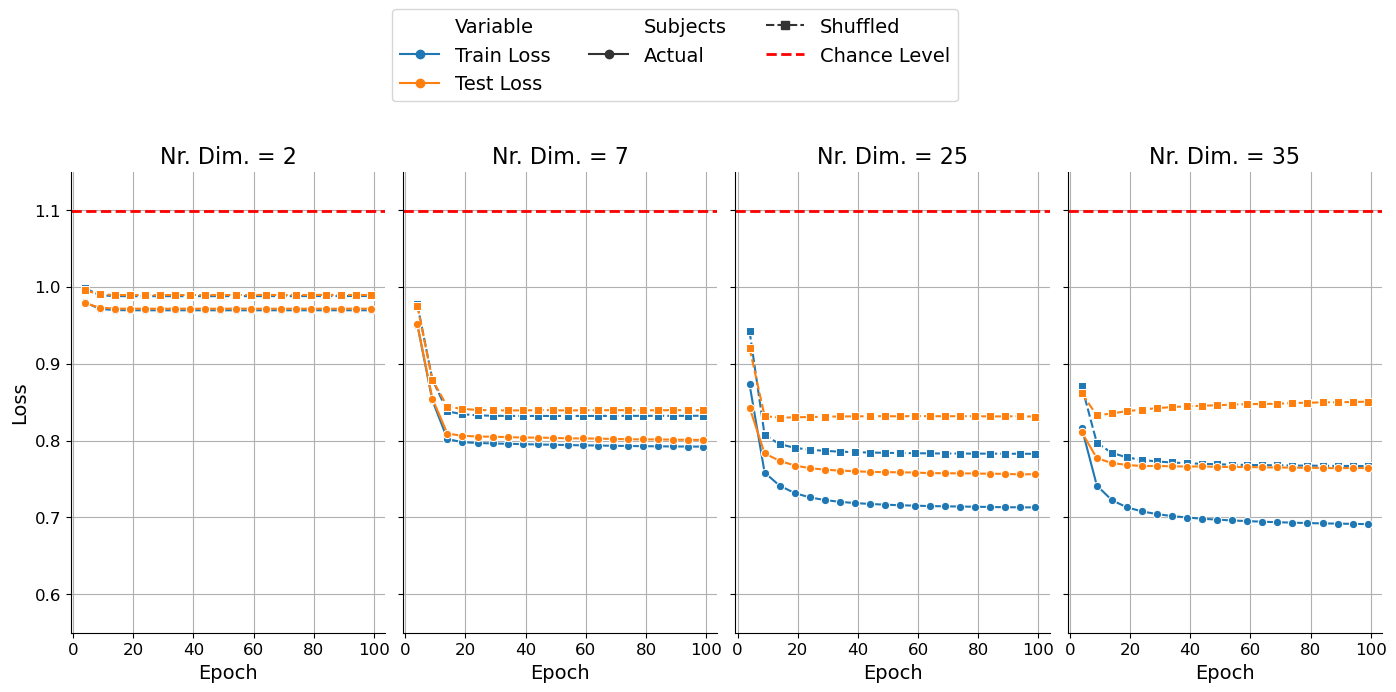

In [15]:
substring1 = "Train"
substring1_1 = "Loss"
marker_styles = {
    "Actual": "o",  # circle
    "Shuffled": "s",  # square
}
# Create the FacetGrid without specifying an external axis
g = sns.relplot(
    data=df_train_eval_long_id_embedding.rename(
        columns={"ndim":"Nr. Dim.", "data_subset":"Subjects", "epoch":"Epoch"}
    ).query(
    (
        "(Epoch + 1) % 5 == 0 & "
        "md == 'free_weights_no_scaling' & "
        "Variable.str.contains(@substring1_1)"
    ),
    engine="python"
), x='Epoch', y='Accuracy', style = "Subjects", col="Nr. Dim.", height=4,
    hue="Variable", marker="o", aspect=1, kind="line", markers=marker_styles
)
g._legend.remove()

# Add horizontal line and collect handles/labels
handles = []
labels = []
for ax in g.axes.flat:
    ax.grid(True)
    line = ax.axhline(y=np.log(3), color='red', linestyle='--', linewidth=2, label='Chance Level')

    ax.set_ylim(.55, 1.15)

    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Use a dictionary to remove duplicates while keeping order
legend_dict = dict(zip(labels, handles))
# Set global font size (affects most elements)
plt.rcParams.update({'font.size': 14})  # You can increase this to 16, 18, etc.

# Manually update each axis in the FacetGrid
for ax in g.axes.flat:
    ax.set_title(ax.get_title(), fontsize=16)
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel("Loss", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

# Update legend font size
g.fig.legend(
    legend_dict.values(),
    legend_dict.keys(),
    loc='lower center',
    bbox_to_anchor=(0.45, 1.015),
    ncol=3,
    frameon=True,
    fontsize=14  # Add this line to scale legend text
)

g.fig.set_size_inches(15, 6)

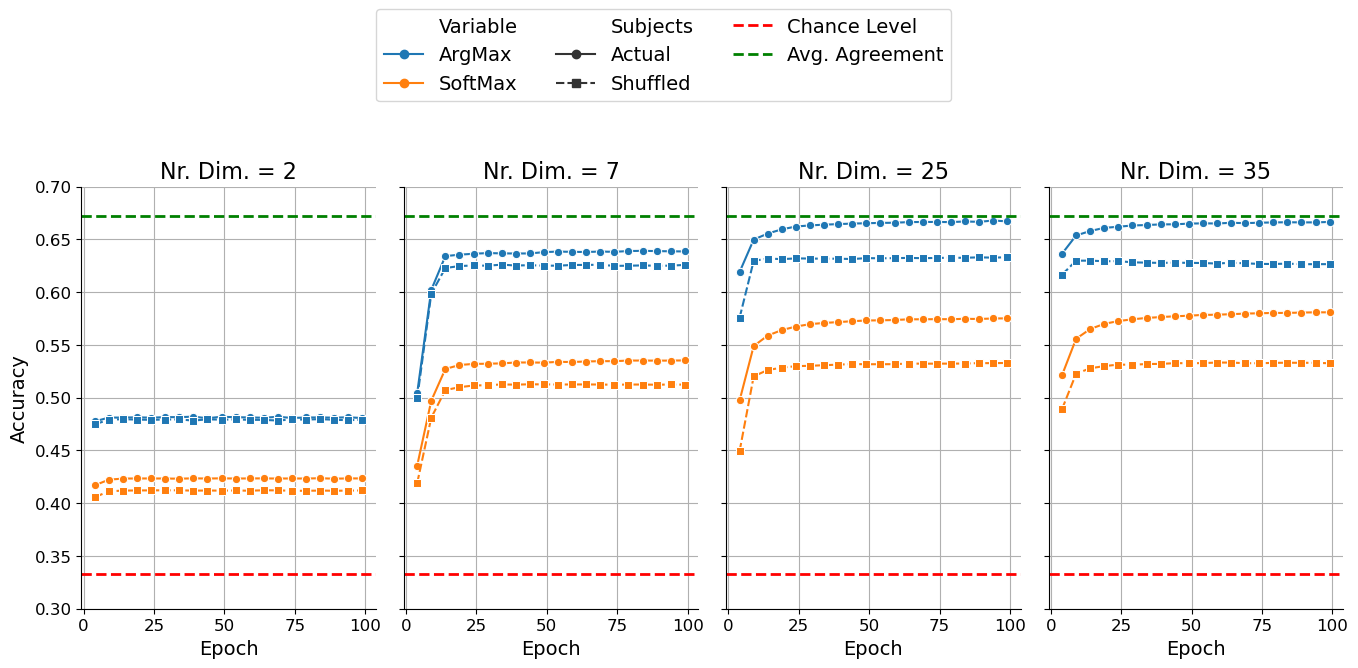

In [16]:
substring2 = "Max"
marker_styles = {
    "Actual": "o",  # circle
    "Shuffled": "s",  # square
}
# Create the FacetGrid without specifying an external axis
g = sns.relplot(
    data=df_train_eval_long_id_embedding.rename(
        columns={"ndim":"Nr. Dim.", "data_subset":"Subjects", "epoch":"Epoch"}
    ).query(
    (
        "(Epoch + 1) % 5 == 0 & "
        "md == 'free_weights_no_scaling' & "
        "Variable.str.contains(@substring2) & "
        "~Variable.str.contains(@substring1)"
    ),
    engine="python"
), x='Epoch', y='Accuracy', style = "Subjects", col="Nr. Dim.", height=4,
    hue="Variable", marker="o", aspect=1, kind="line", markers=marker_styles
)
g._legend.remove()

# Add horizontal line and collect handles/labels
handles = []
labels = []
for ax in g.axes.flat:
    ax.grid(True)
    line = ax.axhline(y=.33333, color='red', linestyle='--', linewidth=2, label='Chance Level')
    line = ax.axhline(y=.6722, color='green', linestyle='--', linewidth=2, label='Avg. Agreement')

    ax.set_ylim(.3, .7)

    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Use a dictionary to remove duplicates while keeping order
legend_dict = dict(zip(labels, handles))
# Set global font size (affects most elements)
plt.rcParams.update({'font.size': 14})  # You can increase this to 16, 18, etc.

# Manually update each axis in the FacetGrid
for ax in g.axes.flat:
    ax.set_title(ax.get_title(), fontsize=16)
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

# Update legend font size
g.fig.legend(
    legend_dict.values(),
    legend_dict.keys(),
    loc='lower center',
    bbox_to_anchor=(0.45, 1.015),
    ncol=3,
    frameon=True,
    fontsize=14  # Add this line to scale legend text
)

g.fig.set_size_inches(15, 6)

In [17]:
substring2 = "Train"
df_embedding_best = df_train_eval_long_id_embedding.query(
    "~Variable.str.contains(@substring2)", engine="python"
).groupby(
    ["md", "data_subset", "ndim", "Variable"]
)["Accuracy"].max().reset_index()
df_embedding_best = df_embedding_best.pivot(
    index=["md", "data_subset", "ndim"], 
    columns=["Variable"], values="Accuracy"
).reset_index()
df_embedding_best_modeltype = df_embedding_best.pivot(
    index=["data_subset", "ndim"], 
    columns="md", values=["ArgMax", "SoftMax"]
).reset_index()
# Assume df_pivot has MultiIndex columns after pivot
df_embedding_best_modeltype.columns = [
    '_'.join(col).rstrip('_') if isinstance(col, tuple) else str(col).rstrip('_') for col in df_embedding_best_modeltype.columns
]

df_embedding_best_modeltype.sort_values("ArgMax_free_weights_no_scaling", ascending=False).head()

,data_subset,ndim,ArgMax_free_weights_no_scaling,SoftMax_free_weights_no_scaling
2,Actual,25,0.667864,0.575243
3,Actual,35,0.666586,0.580941
1,Actual,7,0.639362,0.535365
6,Shuffled,25,0.633187,0.532926
7,Shuffled,35,0.630441,0.533317


### look at by-participant dimensional weights

### Compare random vs. free dimensional weights

In [18]:
l_compare = []
for l in l_models_embedding_only:
    if l["data_subset"] == "subjects_actual" and l["modeltype"] == "free_weights" and l["n_embed"] == 20:
        l["splithalf"] = "1"
        l["item_embeddings"] = l["model_state_dict"]["fc.weight"]
        l["decision_weights"] = l["model_state_dict"]["individual_slopes.weight"]
        l_compare.append(l)
for l in l_models_embedding_only:
    if l["data_subset"] == "subjects_actual" and l["modeltype"] == "random_weights" and l["n_embed"] == 20:
        l["splithalf"] = "2"
        l["item_embeddings"] = l["model_state_dict"]["fc.weight"]
        l["decision_weights"] = l["model_state_dict"]["individual_slopes.weight"]
        l_compare.append(l)

In [20]:
partial_sims = partial(ut.dimensional_similarities, l_compare)
l_cors = list(map(partial_sims, l_embed_dim))

In [21]:
# reorder dimensions in the two halves according to the max. similar result
l_n_tmp = [20]
partial_reorder = partial(ut.reorder_dimensions, l_compare)
l_max_sims = list(map(partial_reorder, l_n_tmp))

In [22]:
df_1 = pd.DataFrame(l_compare[0]["decision_weights"].detach().numpy())
df_1["id"] = range(0, df_1.shape[0])
df_1_long = df_1.melt(id_vars="id", var_name="Dimension", value_name="Weight")

IndexError: list index out of range

In [56]:
df_2 = pd.DataFrame(l_compare[1]["decision_weights"].detach().numpy())
df_2["id"] = range(0, df_1.shape[0])
df_2_long = df_2.melt(id_vars="id", var_name="Dimension", value_name="Weight")

In [57]:
df_compare = pd.merge(df_1_long, df_2_long, on=["id", "Dimension"], how="left", suffixes=["_free_weights", "_random_weights"])

def group_corr(df):
    return np.corrcoef(df["Weight_free_weights"], df["Weight_random_weights"])[0, 1]

df_corr = df_compare.groupby("Dimension").apply(group_corr).reset_index(name="r")

C:\Users\MirkoThalmann\AppData\Local\Temp\ipykernel_19252\3604639864.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_corr = df_compare.groupby("Dimension").apply(group_corr).reset_index(name="r")


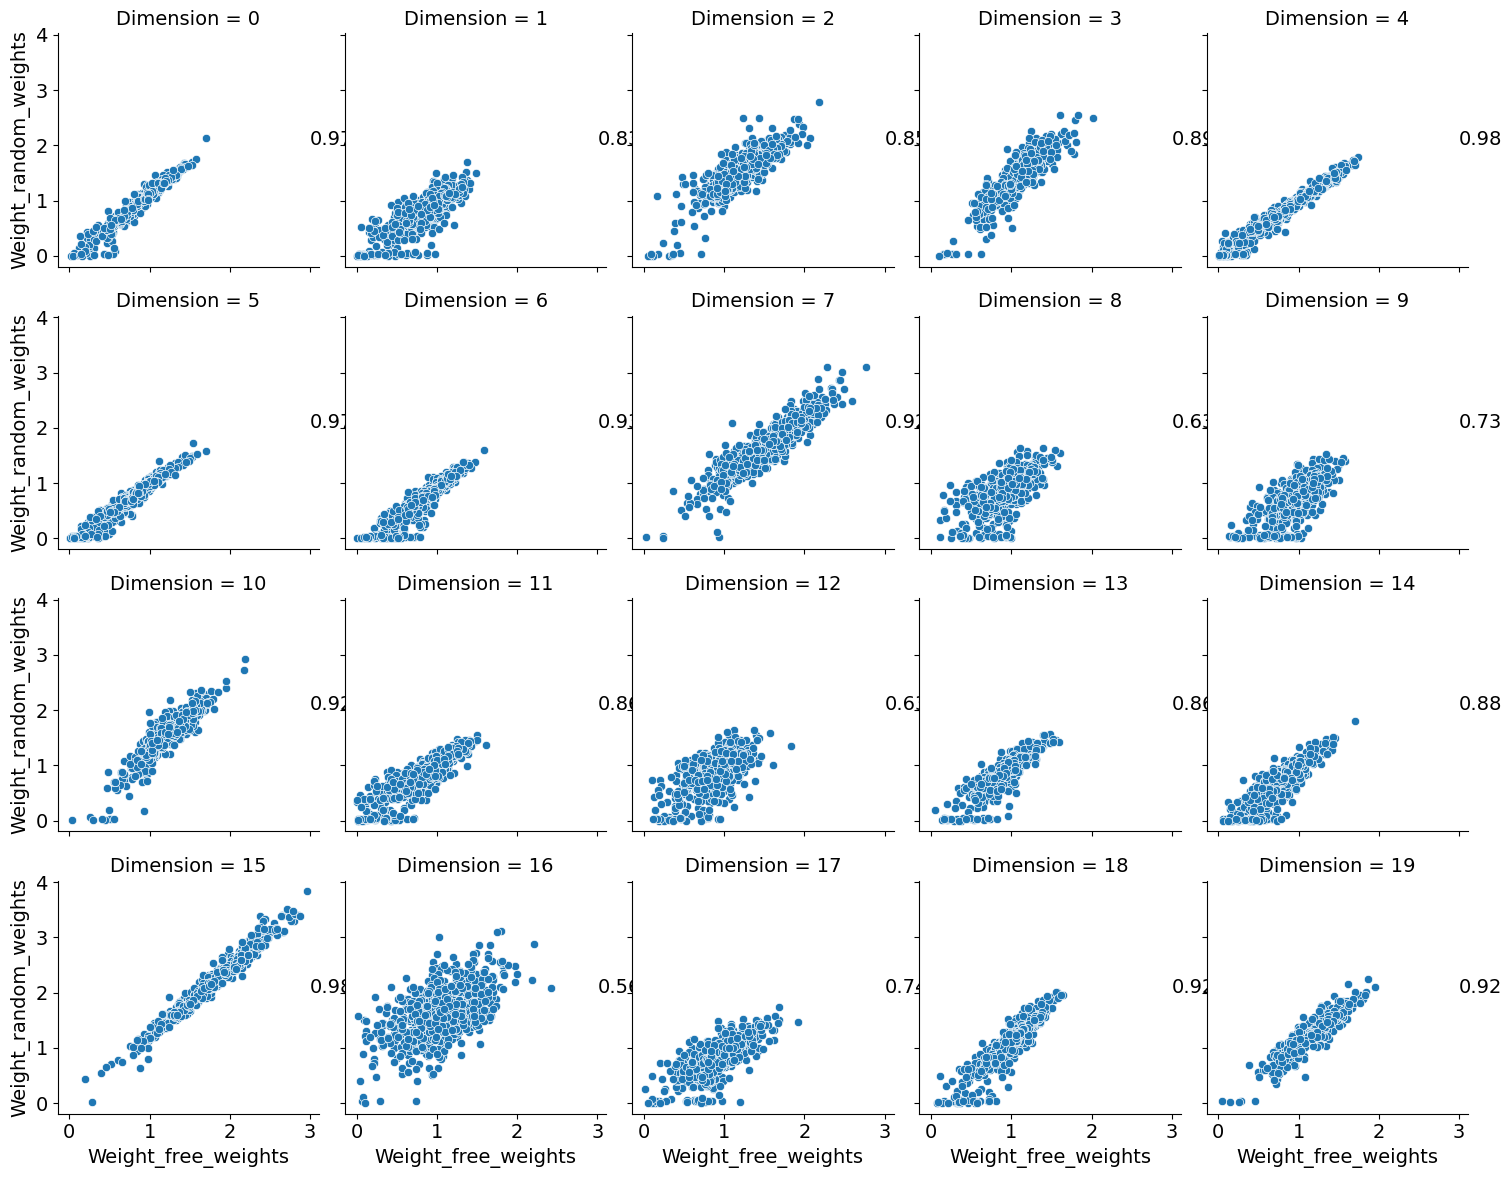

In [58]:
g = sns.FacetGrid(df_compare, col="Dimension", col_wrap=5)
g.map_dataframe(sns.scatterplot, "Weight_free_weights", "Weight_random_weights")
for idx, ax in enumerate(g.axes.flat):
    ax.text(x=3, y=2, s=np.round(df_corr.loc[idx, "r"], 2))

In [61]:
for i, l in enumerate(l_models_embedding_only):
    print("i = ", i)
    print("data_subset = ", l["data_subset"])
    print("modeltype = ", l["modeltype"])
    print("ndim = ", l["n_embed"])
    print("lmbda hierarchical = ", l["lmbda_hierarchical"])
    print("temperature = ", l["temperature"], "\n")

i =  0
subject_type =  subjects_actual
modeltype =  random_weights
ndim =  15
lmbda hierarchical =  0.01
temperature =  tensor(1.) 

i =  1
subject_type =  subjects_shuffled
modeltype =  random_weights
ndim =  15
lmbda hierarchical =  0.01
temperature =  tensor(1.) 

i =  2
subject_type =  subjects_actual
modeltype =  random_weights
ndim =  20
lmbda hierarchical =  0.01
temperature =  tensor(1.) 

i =  3
subject_type =  subjects_shuffled
modeltype =  random_weights
ndim =  20
lmbda hierarchical =  0.01
temperature =  tensor(1.) 

i =  4
subject_type =  subjects_actual
modeltype =  random_weights
ndim =  30
lmbda hierarchical =  0.01
temperature =  tensor(1.) 

i =  5
subject_type =  subjects_shuffled
modeltype =  random_weights
ndim =  30
lmbda hierarchical =  0.01
temperature =  tensor(1.) 

i =  6
subject_type =  subjects_actual
modeltype =  random_weights
ndim =  40
lmbda hierarchical =  0.01
temperature =  tensor(1.) 

i =  7
subject_type =  subjects_shuffled
modeltype =  random_we

In [71]:
idx_random = 0
idx_free = 10

In [62]:
# cannot compare on temp = 50, even though random dim weights perform best, because free weights model performs at chance
df_dim_weights_random = pd.DataFrame(
    l_models_embedding_only[idx_random]["model_state_dict"]["individual_slopes.weight"].detach().numpy()
)
df_dim_weights_free = pd.DataFrame(
    l_models_embedding_only[idx_free]["model_state_dict"]["individual_slopes.weight"].detach().numpy()
)
df_dim_weights_random["id"] = df_dim_weights_random.index
df_dim_weights_random_long = df_dim_weights_random.melt(id_vars="id", var_name="Dimension")
df_dim_weights_random_long["modeltype"] = "random"
df_dim_weights_free["id"] = df_dim_weights_free.index
df_dim_weights_free_long = df_dim_weights_free.melt(id_vars="id", var_name="Dimension")
df_dim_weights_free_long["modeltype"] = "free"

df_dim_weights_long_both = pd.concat([df_dim_weights_free_long, df_dim_weights_random_long], axis=0)

In [63]:
# Define a function that returns two values
def summary(group):
    k2, pval = normaltest(group["value"])
    return pd.Series({
        'k2': k2,
        'pval': pval
    })

df_result = df_dim_weights_long_both.groupby(["Dimension", "modeltype"]).apply(summary).reset_index()
df_result_long = pd.melt(df_result, id_vars=["Dimension", "modeltype"])

C:\Users\MirkoThalmann\AppData\Local\Temp\ipykernel_19252\1412867902.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_result = df_dim_weights_long_both.groupby(["Dimension", "modeltype"]).apply(summary).reset_index()


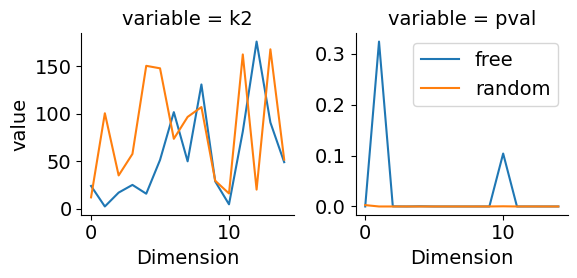

In [64]:
g = sns.FacetGrid(df_result_long, col="variable", sharey=False)
g.map_dataframe(sns.lineplot, x = "Dimension", y = "value", hue="modeltype")
_ = plt.legend()

In [65]:
df_dim_weights_long_both["value_z"] = df_dim_weights_long_both.groupby(["Dimension", "modeltype"])["value"].transform(zscore)

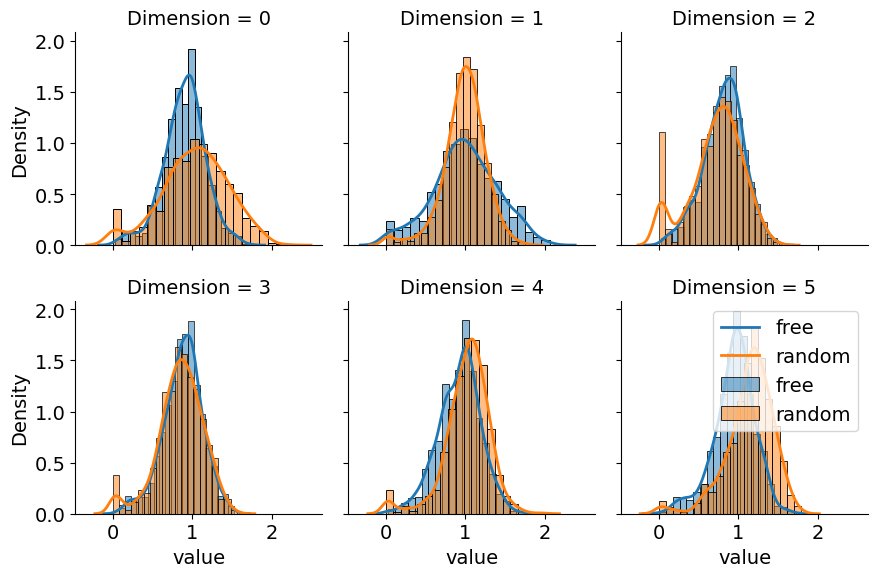

In [66]:
g = sns.FacetGrid(df_dim_weights_long_both.query("Dimension < 6"), col="Dimension", hue="modeltype", col_wrap=3)
g.map(sns.histplot, 'value', bins=20, edgecolor='black', alpha=.5, stat="density")
g.map_dataframe(sns.kdeplot, x="value", fill=False, linewidth=2, common_norm=False, weights=.5)
plt.legend()

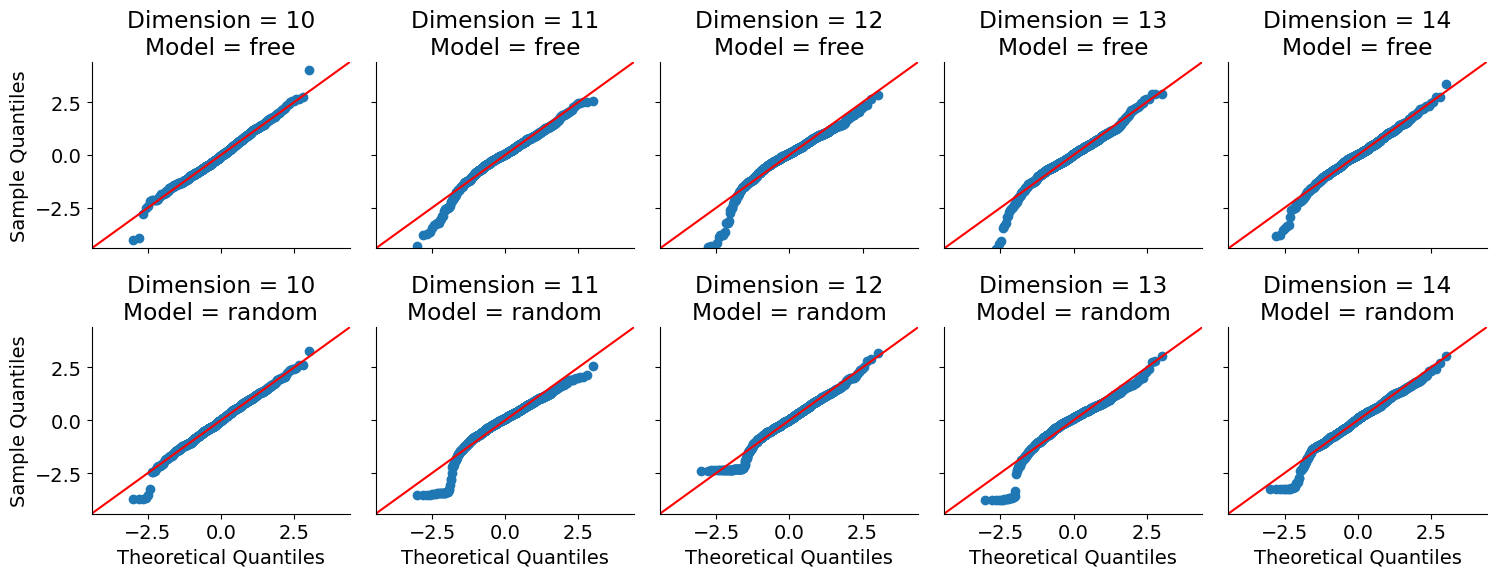

In [68]:
def qqplot_func(data, **kwargs):
    ax = plt.gca()
    sm.qqplot(data['value_z'], line='45', ax=ax)
    ax.set_title(
            f"Dimension = {data['Dimension'].iloc[0]}\nModel = {data['modeltype'].iloc[0]}"
    )
g = sns.FacetGrid(df_dim_weights_long_both.query("Dimension >= 10"), col="Dimension", row="modeltype")
_ = g.map_dataframe(qqplot_func)

#### look at item embeddings

In [83]:
l_models_embedding_only[0].keys()

dict_keys(['item_embeddings', 'decision_weights', 'temperature_scalings', 'modeltype', 'n_embed', 'rnd_seed', 'lmbda', 'data_subset', 'splithalf', 'train_losses', 'train_accs_max', 'train_accs_proba', 'nneg_d_over_time', 'test_accs_max', 'test_accs_proba', 'test_losses', 'id_weights_type'])

In [84]:
df_item_embeddings_random = pd.DataFrame(
    l_models_embedding_only[0]["item_embeddings"].detach().numpy().transpose()
)
df_item_embeddings_random.head()

,0,1
0,0.017154,0.005859
1,0.192675,0.915959
2,0.215915,0.909483
3,0.010760,0.071426
4,0.134167,0.959683


In [72]:
df_item_embeddings_random = pd.DataFrame(
    l_models_embedding_only[idx_random]["model_state_dict"]["fc.weight"].detach().numpy().transpose()
)
df_item_embeddings_free = pd.DataFrame(
    l_models_embedding_only[idx_free]["model_state_dict"]["fc.weight"].detach().numpy().transpose()
)
df_item_embeddings_random["item_id"] = df_item_embeddings_random.index
df_item_embeddings_random["modeltype"] = "random"
df_item_embeddings_free["item_id"] = df_item_embeddings_free.index
df_item_embeddings_free["modeltype"] = "free"

df_item_embeddings_both = pd.concat([df_item_embeddings_random, df_item_embeddings_free], axis=0)

In [73]:
df_plot = df_item_embeddings_both.drop(columns=["item_id", "modeltype"]).transform(sorted, axis=1)
df_plot["modeltype"] = df_item_embeddings_both["modeltype"].copy()
df_plot["sum_embed"] = df_plot.drop(columns="modeltype").sum(axis=1)

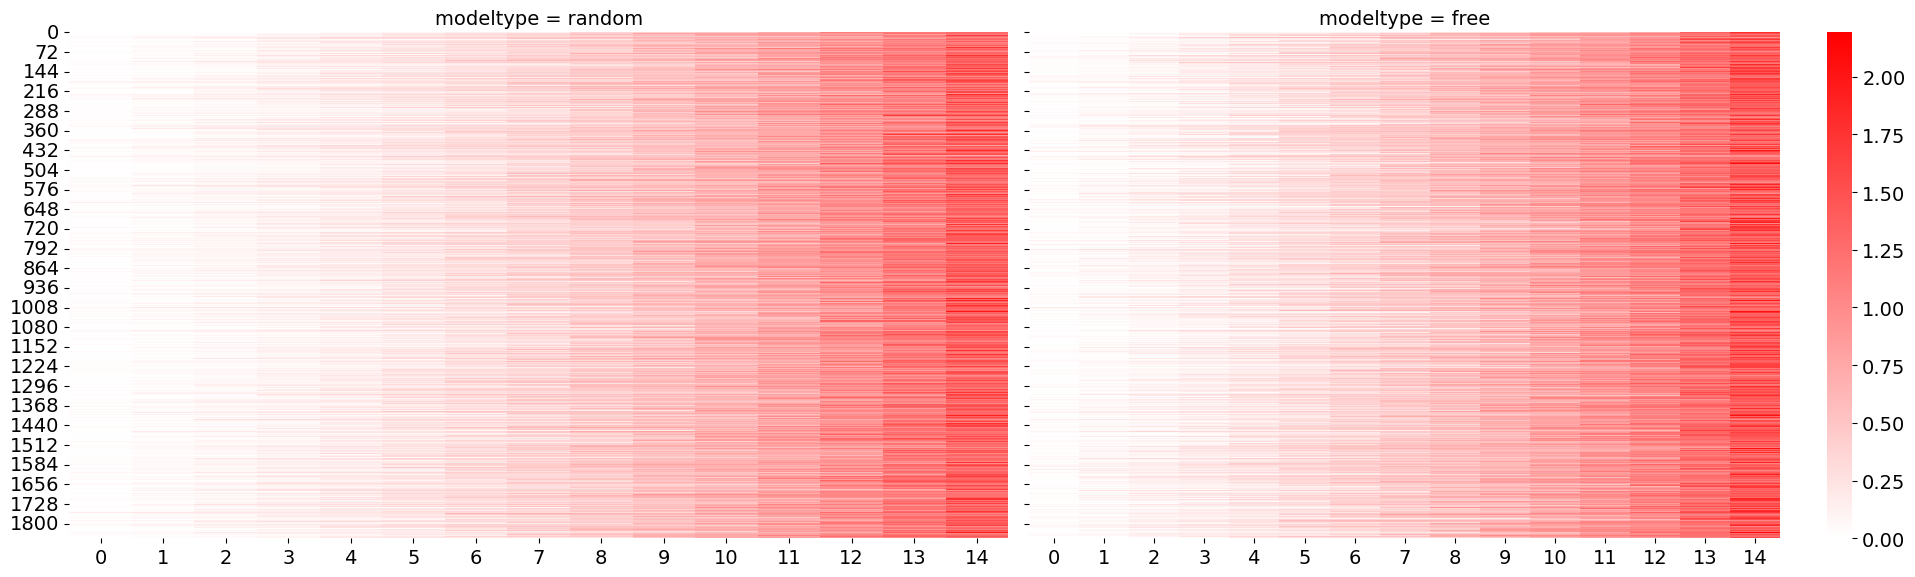

In [74]:
from matplotlib.colors import LinearSegmentedColormap
# Create a custom colormap from white to red
white_red = LinearSegmentedColormap.from_list("white_red", ["white", "red"])
vmin = 0
vmax = df_plot.drop(columns=["modeltype", "sum_embed"]).max(axis=1).max()
height = 6
aspect = 10 / 6 # width / height = aspect

g = sns.FacetGrid(df_plot.drop(columns="sum_embed"), col="modeltype", height=height, aspect=aspect)

# Plot the heatmap
def my_heatmap(data, **kwargs):
    data_use = data.drop(columns=["modeltype"], errors='ignore')
    if data.loc[0, "modeltype"] == "free":
        sns.heatmap(data_use, cmap=white_red, ax=plt.gca(), vmin=vmin, vmax=vmax, cbar=True)
    else:
        sns.heatmap(data_use, cmap=white_red, ax=plt.gca(), vmin=vmin, vmax=vmax, cbar=False)

g.map_dataframe(my_heatmap)
plt.show()

### Compare different hierarchical lambda values

In [76]:
###### by-participant embedding models (no by-participant decision models)
modelversion = "avg-ID-jointly-embeddings"
l_n = [15]
l_temperature = [10.0]
l_subjecttype = ["subjects_actual"]
l_splithalf = ["no"]
l_sparse = ["items_and_random_ids"]
lmbda_hierarchical = [0.01, 0.1]
l_models_lambda_hierarchical = ut.extract_results_id(
    lmbda, lmbda_hierarchical, rnd_seed, modelversion, l_n, l_sparse,
    l_subjecttype, l_splithalf, modeltype="random_weights",
    l_temperature=l_temperature
)

In [77]:
for i, l in enumerate(l_models_lambda_hierarchical):
    print("i = ", i)
    print("data_subset = ", l["data_subset"])
    print("modeltype = ", l["modeltype"])
    print("ndim = ", l["n_embed"])
    print("lmbda hierarchical = ", l["lmbda_hierarchical"])
    print("temperature = ", l["temperature"], "\n")

i =  0
subject_type =  subjects_actual
modeltype =  random_weights
ndim =  15
lmbda hierarchical =  0.01
temperature =  tensor(10.) 

i =  1
subject_type =  subjects_actual
modeltype =  random_weights
ndim =  15
lmbda hierarchical =  0.1
temperature =  tensor(10.) 



In [78]:
idx_low_lambda = 0
idx_hi_lambda = 1

In [79]:
# cannot compare on temp = 50, even though random dim weights perform best, because free weights model performs at chance
df_dim_weights_lo_lambda = pd.DataFrame(
    l_models_lambda_hierarchical[idx_low_lambda]["model_state_dict"]["individual_slopes.weight"].detach().numpy()
)
df_dim_weights_hi_lambda = pd.DataFrame(
    l_models_lambda_hierarchical[idx_hi_lambda]["model_state_dict"]["individual_slopes.weight"].detach().numpy()
)
df_dim_weights_lo_lambda["id"] = df_dim_weights_lo_lambda.index
df_dim_weights_lo_lambda_long = df_dim_weights_lo_lambda.melt(id_vars="id", var_name="Dimension")
df_dim_weights_lo_lambda_long["lambda hierarchical"] = 0.01
df_dim_weights_hi_lambda["id"] = df_dim_weights_hi_lambda.index
df_dim_weights_hi_lambda_long = df_dim_weights_hi_lambda.melt(id_vars="id", var_name="Dimension")
df_dim_weights_hi_lambda_long["lambda hierarchical"] = 5.0

df_dim_weights_lambda_long_both = pd.concat([df_dim_weights_hi_lambda_long, df_dim_weights_lo_lambda_long], axis=0)

In [80]:
# Define a function that returns two values
def summary(group):
    k2, pval = normaltest(group["value"])
    return pd.Series({
        'k2': k2,
        'pval': pval
    })

df_result_lambda = df_dim_weights_lambda_long_both.groupby(["Dimension", "lambda hierarchical"]).apply(summary).reset_index()
df_result_lambda_long = pd.melt(df_result_lambda, id_vars=["Dimension", "lambda hierarchical"])

C:\Users\MirkoThalmann\AppData\Local\Temp\ipykernel_19252\3337732599.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_result_lambda = df_dim_weights_lambda_long_both.groupby(["Dimension", "lambda hierarchical"]).apply(summary).reset_index()


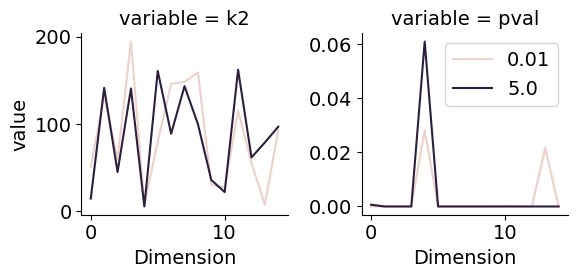

In [82]:
g = sns.FacetGrid(df_result_lambda_long, col="variable", sharey=False)
g.map_dataframe(sns.lineplot, x = "Dimension", y = "value", hue="lambda hierarchical")
_ = plt.legend()

In [83]:
df_dim_weights_lambda_long_both["value_z"] = df_dim_weights_lambda_long_both.groupby(["Dimension", "lambda hierarchical"])["value"].transform(zscore)

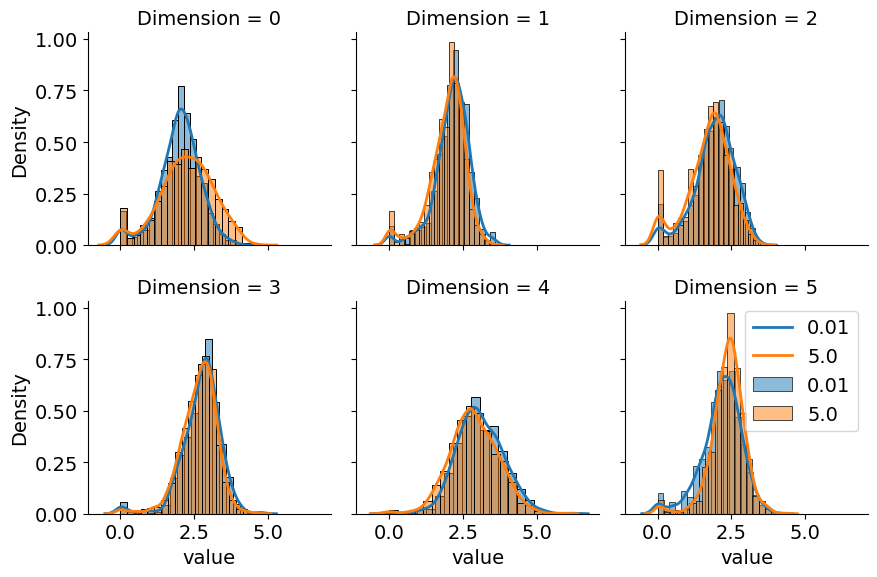

In [84]:
g = sns.FacetGrid(df_dim_weights_lambda_long_both.query("Dimension < 6"), col="Dimension", hue="lambda hierarchical", col_wrap=3)
g.map(sns.histplot, 'value', bins=20, edgecolor='black', alpha=.5, stat="density")
g.map_dataframe(sns.kdeplot, x="value", fill=False, linewidth=2, common_norm=False, weights=.5)
plt.legend()

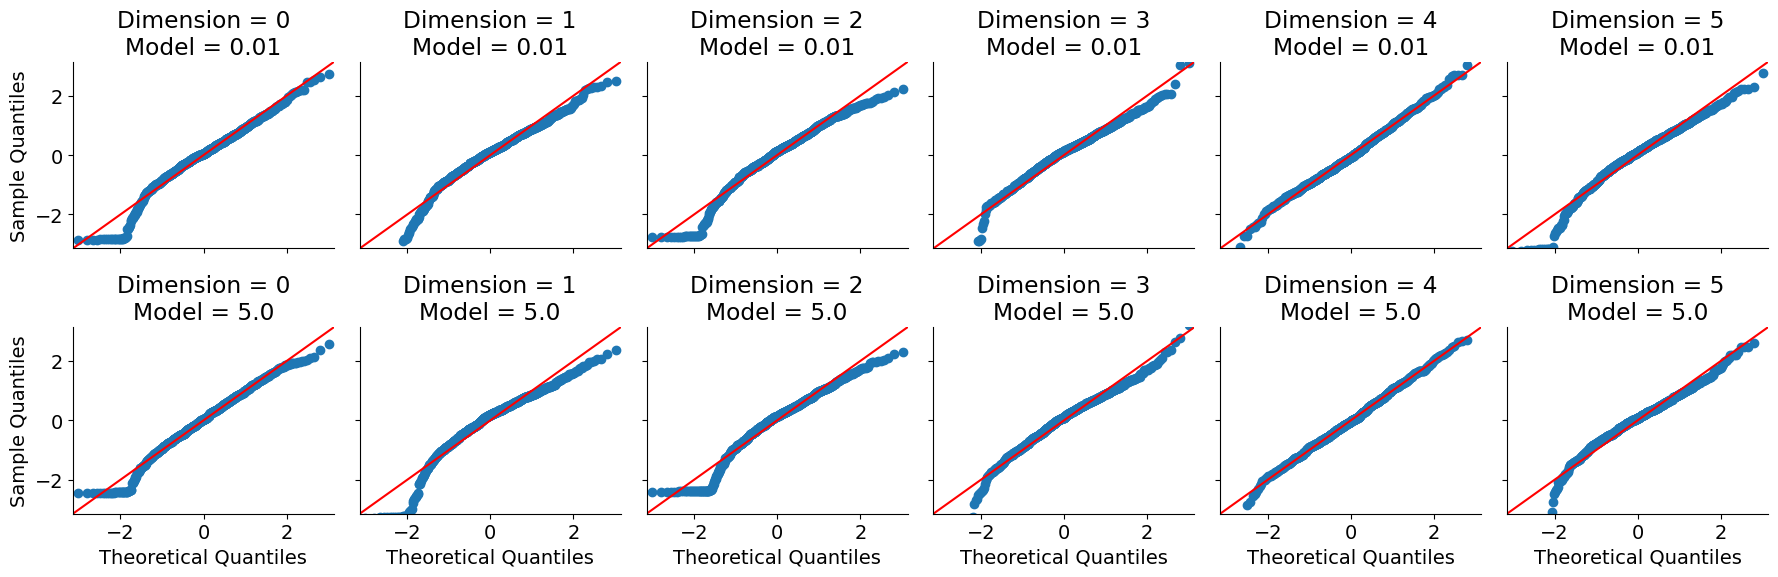

In [85]:
def qqplot_func(data, **kwargs):
    ax = plt.gca()
    sm.qqplot(data['value_z'], line='45', ax=ax)
    ax.set_title(
            f"Dimension = {data['Dimension'].iloc[0]}\nModel = {data['lambda hierarchical'].iloc[0]}"
    )
g = sns.FacetGrid(df_dim_weights_lambda_long_both.query("Dimension <= 5"), col="Dimension", row="lambda hierarchical")
_ = g.map_dataframe(qqplot_func)

### Compare different temperatures

merely descriptive...

#### overview embedding values for ndim = 15
for different temperatures t

- t = 10 --> 0 - 4.2
- t = 1 --> 0 - 2.2
- t = .01 --> 0 - .85

#### overview dimensional weights (average)
- t = 10 --> 2
- t = 1 --> 1
- t = .01 --> .25

--> embedding values and dimensional weights scale with temperature.

i.e., the more deterministic, the smaller both, and vice versa

In [86]:
tmp = pd.DataFrame(
    l_models_embedding_only[0]["model_state_dict"]["fc.weight"].detach().numpy().transpose()
)
tmp["temp"] = 50
tmp1 = pd.DataFrame(
    l_models_embedding_only[1]["model_state_dict"]["fc.weight"].detach().numpy().transpose()
)
tmp1["temp"] = 10
tmp2 = pd.DataFrame(
    l_models_embedding_only[2]["model_state_dict"]["fc.weight"].detach().numpy().transpose()
)
tmp2["temp"] = 1
tmp3 = pd.DataFrame(
    l_models_embedding_only[3]["model_state_dict"]["fc.weight"].detach().numpy().transpose()
)
tmp3["temp"] = .01

df_item_embeddings = pd.concat([tmp, tmp1, tmp2, tmp3], axis=0)

In [87]:
df_item_embeddings.groupby("temp").mean()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
temp,,,,,,,,,,,,,,,,,,,,
0.01,0.230523,0.411897,0.229078,0.382033,0.280804,0.377539,0.333836,0.377875,0.417782,0.357949,0.330841,0.398697,0.248659,0.322005,0.345721,0.286415,0.395118,0.396974,0.298153,0.331319
1.00,0.549345,0.510066,0.324426,0.333084,0.942743,0.723456,0.482147,0.482681,0.414871,0.544609,0.302252,0.611236,0.505862,0.492984,0.606012,0.265299,0.351470,0.586655,0.392978,0.447377
10.00,0.339964,0.255690,0.268037,0.335577,0.347298,0.386672,0.420881,0.254236,0.468374,0.401407,0.388631,0.397911,0.415726,0.321760,0.235581,NaN,NaN,NaN,NaN,NaN
50.00,0.893557,0.440889,0.491535,0.628752,0.492089,0.465631,0.592115,0.510234,0.376907,0.306499,0.337782,0.479113,0.276788,0.337843,0.489506,NaN,NaN,NaN,NaN,NaN


In [88]:
tmp = pd.DataFrame(
    l_models_embedding_only[0]["model_state_dict"]["individual_slopes.weight"].detach().numpy()
)
tmp["temp"] = 50
tmp1 = pd.DataFrame(
    l_models_embedding_only[1]["model_state_dict"]["individual_slopes.weight"].detach().numpy()
)
tmp1["temp"] = 10
tmp2 = pd.DataFrame(
    l_models_embedding_only[2]["model_state_dict"]["individual_slopes.weight"].detach().numpy()
)
tmp2["temp"] = 1
tmp3 = pd.DataFrame(
    l_models_embedding_only[3]["model_state_dict"]["individual_slopes.weight"].detach().numpy()
)
tmp3["temp"] = .01

df_dim_weights = pd.concat([tmp, tmp1, tmp2, tmp3], axis=0)

In [89]:
df_dim_weights.groupby("temp").mean()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
temp,,,,,,,,,,,,,,,,,,,,
0.01,2.042911,0.947269,1.750338,0.805785,1.529434,1.171576,1.122972,0.941676,0.991495,1.335892,1.413577,0.958718,2.658229,1.204136,1.516402,0.950766,0.899053,1.004858,1.573020,1.260995
1.00,0.929758,0.896441,1.537598,1.435571,0.818942,0.712660,0.664463,0.755469,0.923048,0.859194,1.524266,0.791467,0.872711,0.889758,0.678660,2.184688,1.614872,0.798683,1.102194,1.261901
10.00,1.257172,2.644826,1.639742,1.562179,1.466574,1.364138,1.083411,1.482436,0.922167,1.152598,1.318309,1.087029,1.051750,1.667009,2.100968,NaN,NaN,NaN,NaN,NaN
50.00,1.031661,0.986969,0.729421,0.848548,1.022683,1.149994,0.808479,1.043009,1.556010,2.233173,1.754142,1.032774,1.201275,1.379590,1.079663,NaN,NaN,NaN,NaN,NaN


In [90]:
df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["data_subset"] == "subjects_actual", "data_subset"] = "Actual"
df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["data_subset"] == "subjects_shuffled", "data_subset"] = "Shuffled"

df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["Variable"] == "test_acc_max", "Variable"] = "ArgMax"
df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["Variable"] == "test_acc_proba", "Variable"] = "SoftMax"
df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["Variable"] == "train_acc_max", "Variable"] = "ArgMax Train"
df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["Variable"] == "train_acc_proba", "Variable"] = "SoftMax Train"

In [91]:
df_train_eval_long_id_decision.head(10)

,md,sparsity,subject_type,ndim,l,lh,epoch,Variable,Accuracy,lambda_ndim,modeltype_lh
0,random_weights_random_scaling,items_and_random_ids,Actual,6,0.0005,0.01,0,ArgMax Train,0.457242,0.0005_6,random_weights_random_scaling_0.01
1,random_weights_random_scaling,items_and_random_ids,Actual,6,0.0005,0.01,1,ArgMax Train,0.485282,0.0005_6,random_weights_random_scaling_0.01
2,random_weights_random_scaling,items_and_random_ids,Actual,6,0.0005,0.01,2,ArgMax Train,0.544699,0.0005_6,random_weights_random_scaling_0.01
3,random_weights_random_scaling,items_and_random_ids,Actual,6,0.0005,0.01,3,ArgMax Train,0.620323,0.0005_6,random_weights_random_scaling_0.01
4,random_weights_random_scaling,items_and_random_ids,Actual,6,0.0005,0.01,4,ArgMax Train,0.628811,0.0005_6,random_weights_random_scaling_0.01
5,random_weights_random_scaling,items_and_random_ids,Actual,6,0.0005,0.01,5,ArgMax Train,0.629838,0.0005_6,random_weights_random_scaling_0.01
6,random_weights_random_scaling,items_and_random_ids,Actual,6,0.0005,0.01,6,ArgMax Train,0.630679,0.0005_6,random_weights_random_scaling_0.01
7,random_weights_random_scaling,items_and_random_ids,Actual,6,0.0005,0.01,7,ArgMax Train,0.630830,0.0005_6,random_weights_random_scaling_0.01
8,random_weights_random_scaling,items_and_random_ids,Actual,6,0.0005,0.01,8,ArgMax Train,0.631173,0.0005_6,random_weights_random_scaling_0.01
9,random_weights_random_scaling,items_and_random_ids,Actual,6,0.0005,0.01,9,ArgMax Train,0.631265,0.0005_6,random_weights_random_scaling_0.01


In [92]:
substring2 = "Max"
df_train_eval_long_id_decision.rename(
        columns={"ndim":"Nr. Dim.", "data_subset":"Subjects", "epoch":"Epoch"}
    ).query("(Epoch + 1) % 5 == 0 & md == 'random_weights_free_scaling' & Variable.str.contains(@substring2)", engine="python")

,md,sparsity,Subjects,Nr. Dim.,l,lh,Epoch,Variable,Accuracy,lambda_ndim,modeltype_lh
1204,random_weights_free_scaling,items_and_random_ids,Actual,5,0.0005,0.01,4,ArgMax Train,0.596064,0.0005_5,random_weights_free_scaling_0.01
1209,random_weights_free_scaling,items_and_random_ids,Actual,5,0.0005,0.01,9,ArgMax Train,0.622038,0.0005_5,random_weights_free_scaling_0.01
1214,random_weights_free_scaling,items_and_random_ids,Actual,5,0.0005,0.01,14,ArgMax Train,0.623867,0.0005_5,random_weights_free_scaling_0.01
1219,random_weights_free_scaling,items_and_random_ids,Actual,5,0.0005,0.01,19,ArgMax Train,0.624351,0.0005_5,random_weights_free_scaling_0.01
1224,random_weights_free_scaling,items_and_random_ids,Actual,5,0.0005,0.01,24,ArgMax Train,0.625433,0.0005_5,random_weights_free_scaling_0.01
...,...,...,...,...,...,...,...,...,...,...,...
13179,random_weights_free_scaling,items_and_random_ids,Shuffled,50,0.0005,0.01,129,SoftMax,0.530523,0.0005_50,random_weights_free_scaling_0.01
13184,random_weights_free_scaling,items_and_random_ids,Shuffled,50,0.0005,0.01,134,SoftMax,0.530652,0.0005_50,random_weights_free_scaling_0.01
13189,random_weights_free_scaling,items_and_random_ids,Shuffled,50,0.0005,0.01,139,SoftMax,0.530864,0.0005_50,random_weights_free_scaling_0.01
13194,random_weights_free_scaling,items_and_random_ids,Shuffled,50,0.0005,0.01,144,SoftMax,0.530830,0.0005_50,random_weights_free_scaling_0.01


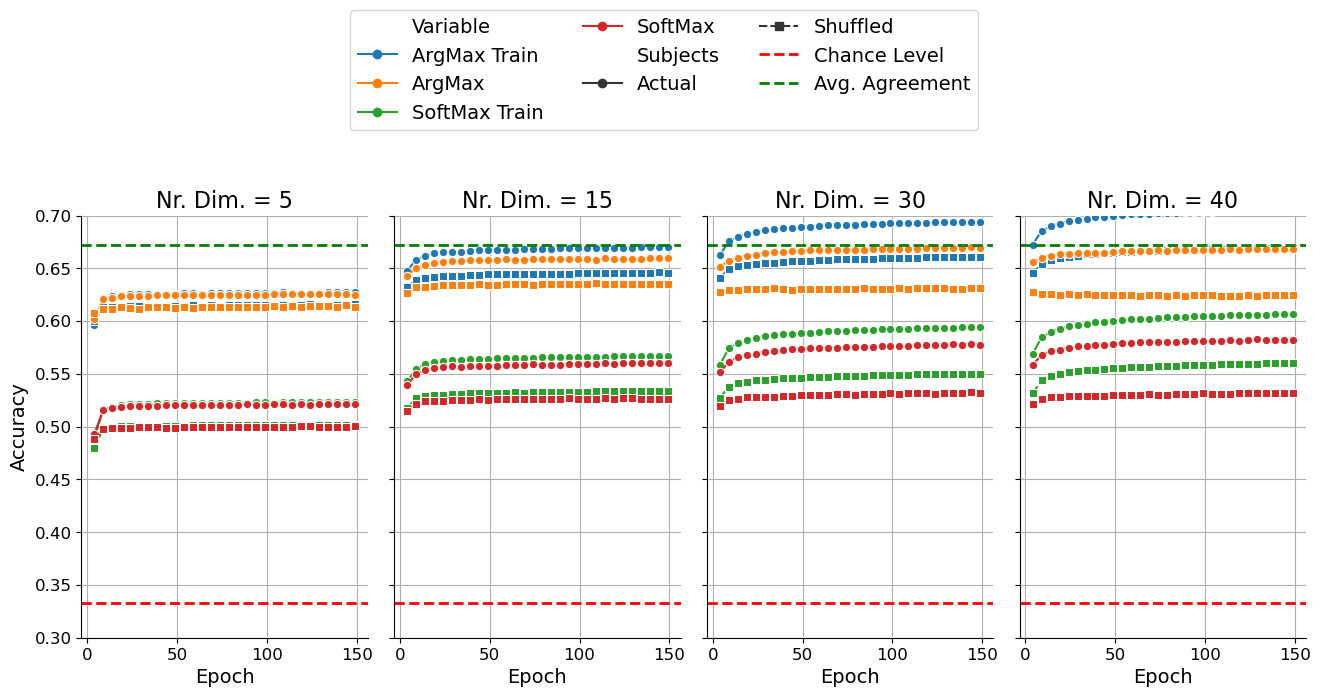

In [93]:
substring2 = "Max"
marker_styles = {
    "Actual": "o",  # circle
    "Shuffled": "s",  # square
}
# Create the FacetGrid without specifying an external axis
g = sns.relplot(
    data=df_train_eval_long_id_decision.query("ndim in (5, 15, 30, 40)").rename(
        columns={"ndim":"Nr. Dim.", "data_subset":"Subjects", "epoch":"Epoch"}
    ).query("(Epoch + 1) % 5 == 0 & md == 'random_weights_free_scaling' & Variable.str.contains(@substring2)",
    engine="python"
), x='Epoch', y='Accuracy', style = "Subjects", col="Nr. Dim.", height=4,
    hue="Variable", marker="o", aspect=1, kind="line", markers=marker_styles
)
g._legend.remove()

# Add horizontal line and collect handles/labels
handles = []
labels = []
for ax in g.axes.flat:
    ax.grid(True)
    line = ax.axhline(y=.33333, color='red', linestyle='--', linewidth=2, label='Chance Level')
    line = ax.axhline(y=.6722, color='green', linestyle='--', linewidth=2, label='Avg. Agreement')

    ax.set_ylim(.3, .7)

    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Use a dictionary to remove duplicates while keeping order
legend_dict = dict(zip(labels, handles))
# Set global font size (affects most elements)
plt.rcParams.update({'font.size': 14})  # You can increase this to 16, 18, etc.

# Manually update each axis in the FacetGrid
for ax in g.axes.flat:
    ax.set_title(ax.get_title(), fontsize=16)
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

# Update legend font size
g.fig.legend(
    legend_dict.values(),
    legend_dict.keys(),
    loc='lower center',
    bbox_to_anchor=(0.45, 1.015),
    ncol=3,
    frameon=True,
    fontsize=14  # Add this line to scale legend text
)

g.fig.set_size_inches(15, 6)

## embedding plus decision model

### compare hyperparameter settings

In [88]:
df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["data_subset"] == "full_evaluate_actual", "data_subset"] = "Actual"
df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["data_subset"] == "full_evaluate_shuffled", "data_subset"] = "Shuffled"

df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["Variable"] == "test_acc_max", "Variable"] = "ArgMax"
df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["Variable"] == "test_acc_proba", "Variable"] = "SoftMax"
df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["Variable"] == "train_acc_max", "Variable"] = "ArgMax Train"
df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["Variable"] == "train_acc_proba", "Variable"] = "SoftMax Train"
df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["Variable"] == "train_losses", "Variable"] = "Train Loss"
df_train_eval_long_id_decision.loc[df_train_eval_long_id_decision["Variable"] == "test_losses", "Variable"] = "Test Loss"

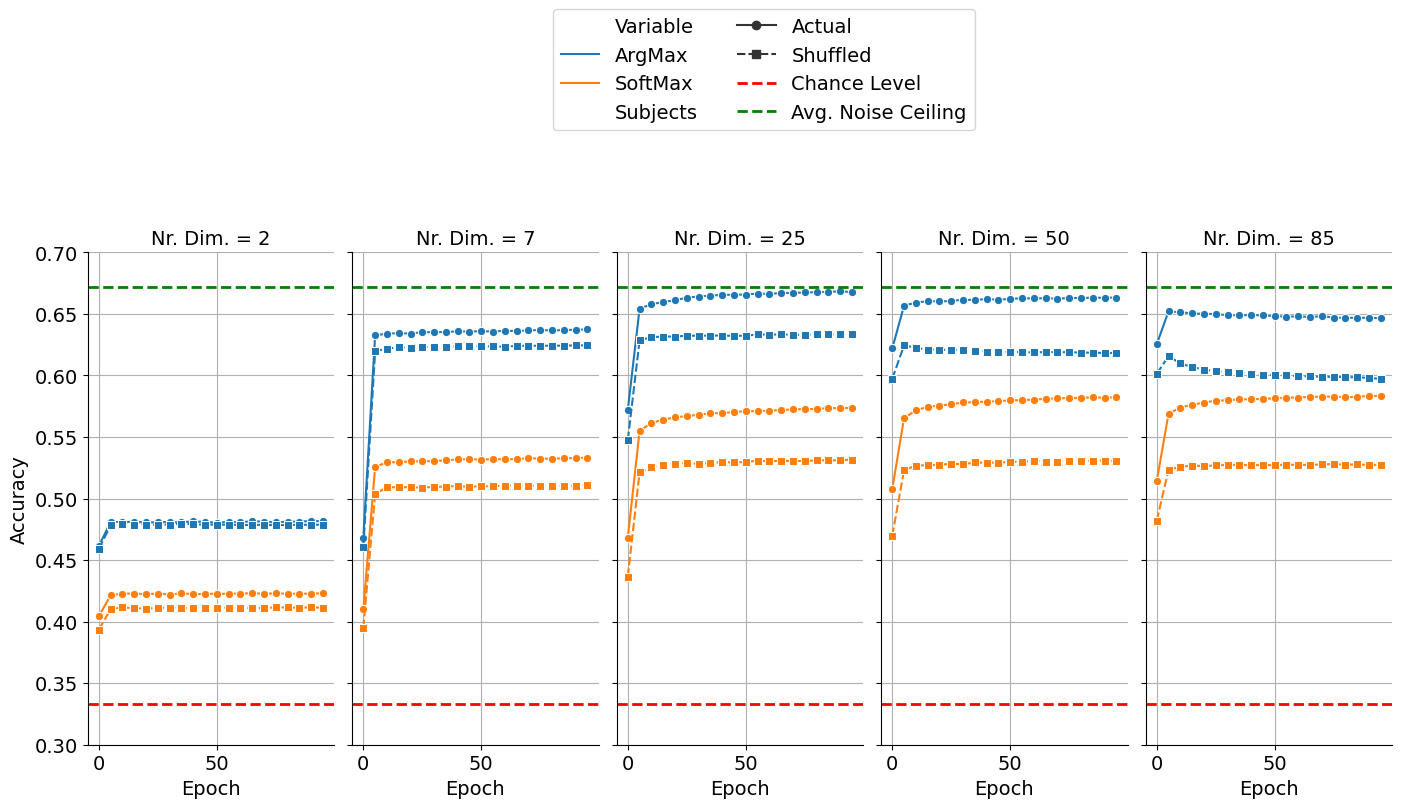

In [104]:
# Create the FacetGrid without specifying an external axis

data=df_train_eval_long_id_decision.rename(
        columns={"ndim":"Nr. Dim.", "data_subset":"Subjects", "epoch":"Epoch"}
    )

g = sns.relplot(
    data=data.query(
        "Epoch % 5 == 0 & ~Variable.str.contains(@substring2) & md == 'free_weights_free_scaling' & ~Variable.str.contains(@substring1_1)",
        engine="python"
    ),
    x='Epoch', y='Accuracy', col='Nr. Dim.', height=4, col_wrap=5, 
    hue="Variable", style="Subjects", markers=marker_styles,
    kind="line", aspect=1
)

g._legend.remove()

# Add horizontal line and collect handles/labels
handles = []
labels = []
for ax in g.axes.flat:
    ax.grid(True)
    ax.axhline(y=.33333, color='red', linestyle='--', linewidth=2, label='Chance Level')
    ax.axhline(y=.6722, color='green', linestyle='--', linewidth=2, label='Avg. Noise Ceiling')
    ax.set_ylim(.3, .7)

    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Use a dictionary to remove duplicates while keeping order
legend_dict = dict(zip(labels, handles))
g.fig.legend(
    legend_dict.values(),
    legend_dict.keys(),
    loc='lower center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=2,
    frameon=True
)

g.fig.set_size_inches(15, 7)


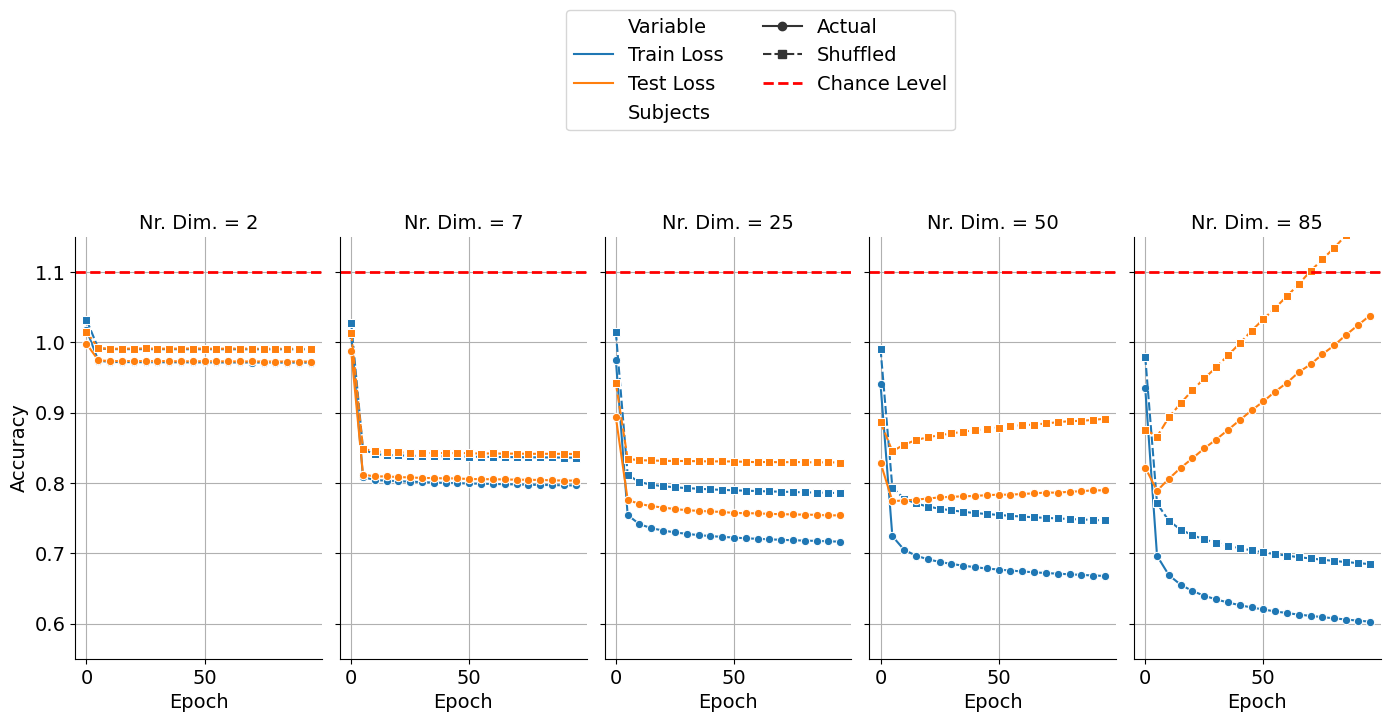

In [109]:
# Create the FacetGrid without specifying an external axis
data=df_train_eval_long_id_decision.rename(
        columns={"ndim":"Nr. Dim.", "data_subset":"Subjects", "epoch":"Epoch"}
    )

g = sns.relplot(
    data=data.query(
        "Epoch % 5 == 0 & Variable.str.contains(@substring1_1) & md == 'free_weights_free_scaling'",
        engine="python"
    ),
    x='Epoch', y='Accuracy', col='Nr. Dim.', height=4, col_wrap=5, 
    hue="Variable", style="Subjects", markers=marker_styles,
    kind="line", aspect=1
)

g._legend.remove()

# Add horizontal line and collect handles/labels
handles = []
labels = []
for ax in g.axes.flat:
    ax.grid(True)
    ax.axhline(y=1.1, color='red', linestyle='--', linewidth=2, label='Chance Level')
    ax.set_ylim(.55, 1.15)

    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Use a dictionary to remove duplicates while keeping order
legend_dict = dict(zip(labels, handles))
g.fig.legend(
    legend_dict.values(),
    legend_dict.keys(),
    loc='lower center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=2,
    frameon=True
)

g.fig.set_size_inches(15, 6)


In [110]:
substring2 = "Train"
df_embedding_decision_best = df_train_eval_long_id_decision.query(
    "~Variable.str.contains(@substring2)", engine="python"
).groupby(
    ["md", "data_subset", "ndim", "Variable"]
)["Accuracy"].max().reset_index()

df_embedding_decision_best = df_embedding_decision_best.pivot(
    index=["md", "data_subset", "ndim"], 
    columns=["Variable"], values="Accuracy"
).reset_index()
df_embedding_decision_best_modeltype = df_embedding_decision_best.pivot(
    index=["data_subset", "ndim"], 
    columns="md", values=["ArgMax", "SoftMax"]
).reset_index()
# Assume df_pivot has MultiIndex columns after pivot
df_embedding_decision_best_modeltype.columns = [
    '_'.join(col).rstrip('_') if isinstance(col, tuple) else str(col).rstrip('_') for col in df_embedding_decision_best_modeltype.columns
]

### Distribution of by-participant decision weights

In [108]:
for i, l in enumerate(l_models_decision):
    print("i = ", i)
    print("data_subset = ", l["data_subset"])
    print("modeltype = ", l["modeltype"])
    print("ndim = ", l["n_embed"])
    print("lmbda hierarchical = ", l["lmbda_hierarchical"], "\n")


i =  0
subject_type =  subjects_actual
modeltype =  random_weights_random_scaling
ndim =  6
lmbda hierarchical =  0.01 

i =  1
subject_type =  subjects_shuffled
modeltype =  random_weights_random_scaling
ndim =  6
lmbda hierarchical =  0.01 

i =  2
subject_type =  subjects_actual
modeltype =  random_weights_random_scaling
ndim =  15
lmbda hierarchical =  0.01 

i =  3
subject_type =  subjects_shuffled
modeltype =  random_weights_random_scaling
ndim =  15
lmbda hierarchical =  0.01 

i =  4
subject_type =  subjects_actual
modeltype =  random_weights_random_scaling
ndim =  30
lmbda hierarchical =  0.01 

i =  5
subject_type =  subjects_shuffled
modeltype =  random_weights_random_scaling
ndim =  30
lmbda hierarchical =  0.01 

i =  6
subject_type =  subjects_actual
modeltype =  random_weights_random_scaling
ndim =  50
lmbda hierarchical =  0.01 

i =  7
subject_type =  subjects_shuffled
modeltype =  random_weights_random_scaling
ndim =  50
lmbda hierarchical =  0.01 

i =  8
subject_typ

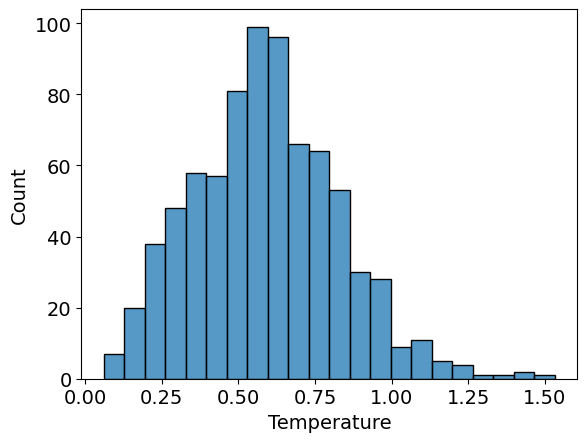

In [109]:
df_temps_free = pd.DataFrame(
    l_models_decision[4]["model_state_dict"]["model2.individual_temps.weight"].detach().numpy()
)

df_temps_free["id"] = df_temps_free.index
df_temps_free["temp_unscaled"] = np.exp(df_temps_free[0])
sns.histplot(data=df_temps_free, x="temp_unscaled")
_ = plt.xlabel("Temperature")

## Is random worse than free? Does adding by-participant temperatures help?

In [ ]:
df_embedding_best_modeltype.sort_values(["temperature", "data_subset", "ndim"]).head(10)

In [ ]:
df_compare_models = pd.merge(
    df_embedding_best_modeltype.dropna(), 
    df_embedding_decision_best_modeltype.dropna(), 
    how = "left", on = ["data_subset", "ndim"]
)
df_compare_models["Free - Random Weights: Max."] = df_compare_models["test_acc_max_free_weights"] - df_compare_models["test_acc_max_random_weights"]
df_compare_models["Free - Random Weights: Prob."] = df_compare_models["test_acc_proba_free_weights"] - df_compare_models["test_acc_proba_random_weights"]
df_compare_models["Vary t: Max."] = df_compare_models["test_acc_max_random_weights_free_scaling"] - df_compare_models["test_acc_max_random_weights"]
df_compare_models["Vary t: Prob."] = df_compare_models["test_acc_proba_random_weights_free_scaling"] - df_compare_models["test_acc_proba_random_weights"]
df_hist = df_compare_models[["Free - Random Weights: Max.", "Free - Random Weights: Prob.", "Vary t: Max.", "Vary t: Prob."]].melt()
g = sns.FacetGrid(df_hist, col="variable", sharex=False)
g.map_dataframe(sns.histplot, x="value", binwidth=.001)

for i, ax in enumerate(g.axes.flat): 
    ax.grid(True)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Difference')
    ax.set_xlabel("Delta")
    ax.set_xlim(-0.025, 0.025)

g.set_titles("{col_name}")  # If you just want the column name
_ = plt.legend()

In [ ]:
df_compare_models.sort_values("Vary t: Prob.", ascending=False)

Evaluate winning model against best avg model

In [ ]:
# Create the FacetGrid without specifying an external axis
g = sns.relplot(
    data=df_train_eval_long_avg.query("epoch <= 749 & epoch % 25 == 0"), x='epoch', y='Accuracy', 
    col='ndim', row="lambda", height=4, hue="Variable",
    marker="o", aspect=1, kind="line")
# Add gridlines to each facet 
for i, ax in enumerate(g.axes.flat): 
    ax.grid(True)
    ax.axhline(y=.33333, color='red', linestyle='--', linewidth=2, label='Chance Level')
    
    #ax.set_xlim(0, 400)
    ax.set_ylim(0, 1)
    if i == 0:
        ax.legend()

# Adjust the plot size
g.fig.set_size_inches(8, 4)
g.fig.set_dpi(150)

plt.show()

In [ ]:
df_avg_best = df_train_eval_long_avg.query("`lambda` == 0.0005 & ndim == 15").copy()
df_avg_best["id_level"] = "avg"

In [ ]:
cols_shared = np.intersect1d(df_id_best.columns, df_avg_best.columns)
df_best_both = pd.concat([df_id_best[cols_shared], df_avg_best[cols_shared]])

In [ ]:
# Create the FacetGrid without specifying an external axis
palette = sns.color_palette("Set2")[2:]
g = sns.relplot(
    data=df_best_both.query("Variable == 'val_acc' & epoch <= 100"), x='epoch', y='Accuracy', 
    height=4, hue="id_level", palette=palette,
    marker="o", aspect=1, kind="line")
# Add gridlines to each facet 
for i, ax in enumerate(g.axes.flat): 
    ax.grid(True)
    #ax.axhline(y=.33333, color='red', linestyle='--', linewidth=2, label='Chance Level')
    
    #ax.set_xlim(0, 400)
    ax.set_ylim(.59, .64)
    if i == 0:
        ax.legend()

# Adjust the plot size
g.fig.set_size_inches(8, 5)
g.fig.set_dpi(150)

plt.show()

In [ ]:
l_all_models_id[3]["model_state_dict"]["fc.weight"].shape

In [ ]:
l_all_models_id[3]["model_state_dict"]["individual_slopes.weight"].shape

# Comparison per Participant

In [ ]:
for i, l in enumerate(l_all_models_id_1):
    print("i = ", i)
    print("n_embed = ", l["n_embed"])
    print("data_subset = ", l["data_subset"], "\n")

In [25]:
triplets_dir = './data/'
device = "cpu"
# load triplets into memory
train_triplets, test_triplets = ut.load_data_ID(
    device=device, triplets_dir=triplets_dir, testcase=False)


...Could not find any .npy files for current modality.
...Now searching for .txt files.



In [41]:
# model with 30 dims
array_weights_items = np.array(l_models_embedding_only[-1]["item_embeddings"]).transpose()
array_weights_id = l_models_embedding_only[-1]["decision_weights"]

In [43]:
anchors = np.array([array_weights_items[i,:] for i in list(test_triplets[:, 0])])
positives = np.array([array_weights_items[i,:] for i in list(test_triplets[:, 1])])
negatives = np.array([array_weights_items[i,:] for i in list(test_triplets[:, 2])])

In [44]:
ids = test_triplets[:, 3].numpy()

In [46]:
anchors_weighted = [a*array_weights_id.numpy()[ids[id], :] for id, a in enumerate(anchors)]
positives_weighted = [a*array_weights_id.numpy()[ids[id], :] for id, a in enumerate(positives)]
negatives_weighted = [a*array_weights_id.numpy()[ids[id], :] for id, a in enumerate(negatives)]

In [52]:
f_partial = partial(ut.delta_avg_id, anchors, positives, negatives, anchors_weighted, positives_weighted, negatives_weighted, ids)

In [53]:
ids_unique_sorted = np.sort(np.unique(ids))

In [54]:
l_deltas = list(map(f_partial, ids_unique_sorted))

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [ ]:
deltas_participant = []
for l in l_deltas:
    deltas_participant.append(l[0])

In [ ]:
df_ns = pd.DataFrame(ids, columns=['id'])
df_ns = df_ns.groupby("id")["id"].count() * 4
df_ns = df_ns.reset_index(name = "n_train")
df_ns["delta"] = deltas_participant

In [ ]:
df_ns.to_csv("data/deltas-learned-weighted-embeddings.csv")

In [ ]:
df_ns = pd.read_csv("data/deltas-learned-weighted-embeddings.csv")

In [ ]:
df_ns.head()

In [ ]:
import statsmodels.api as sm
import seaborn as sns

In [ ]:
df_ns["is_improvement"] = (df_ns["delta"] >= 0).astype(int)
prop_triplets_improved = np.round(np.mean(df_ns["is_improvement"], axis=0), 4)
prop_triplets_improved

In [ ]:
df_ns["n_train_log"] = np.log(df_ns["n_train"])
ax = sns.regplot(
    data=df_ns,
    x="n_train_log",
    y="delta",
    scatter=True,  # Set to False if you only want the smooth line, not the scatter
    line_kws={"color": "blue", "lw": 2, "alpha": .7}, 
    scatter_kws={"alpha": .2}
)

plt.axhline(y=0, color="red", linestyle="--", label="No Improvement")

# Customize x-ticks: convert log values back to original
xticks = ax.get_xticks()
xtick_labels = [f"{int(np.round(np.exp(tick)))}" for tick in xticks]
ax.set_xticklabels(xtick_labels)

# Optional extras
ax.axhline(y=0, color="red", linestyle="--", label="No Improvement")
_ = plt.text(x=7.5, y=.25, s=f"Prop. Improved = {prop_triplets_improved}")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_ns

In [ ]:
df_ns["n_train_log_cut"] = pd.cut(df_ns["n_train"], bins=[0, 390, 410, 440, 525, 744, 1265, 2138, 3544, 6114, 10060, 15379, 27061])
df_ns["n_train_cut_nolabel"] = pd.cut(
    df_ns["n_train"], 
    bins=[0, 390, 410, 440, 525, 744, 1265, 2138, 3544, 6114, 10060, 15379, 27061], 
    labels=[390, 410, 440, 525, 744, 1265, 2138, 3544, 6114, 10060, 15379, 27061]
)
df_ns["n_train_cut_nolabel"] = df_ns["n_train_cut_nolabel"].astype("float")

In [ ]:
df_ns.head()

In [ ]:
df_ns_agg = df_ns.groupby("n_train_cut_nolabel").agg({"delta": ["count", "mean"]})
# Flatten the MultiIndex columns
df_ns_agg.columns = ['_'.join(col).strip() for col in df_ns_agg.columns.values]
df_ns_agg = df_ns_agg.reset_index()
df_ns_agg["n_train_cut_log"] = np.log(df_ns_agg["n_train_cut_nolabel"])
df_ns_agg.head(10)

In [ ]:
df_ns["n_train_log"] = np.log(df_ns["n_train"])
ax = sns.regplot(
    data=df_ns,
    x="n_train_log",
    y="delta",
    scatter=True,  # Set to False if you only want the smooth line, not the scatter
    line_kws={"color": "blue", "lw": 2, "alpha": .7}, 
    scatter_kws={"alpha": .2}
)

plt.axhline(y=0, color="red", linestyle="--")
plt.text(x=7.4, y=-.025, s="No Improvement", color="red")

# Customize x-ticks: convert log values back to original
xticks = ax.get_xticks()
xtick_labels = [f"{int(np.round(np.exp(tick)))}" for tick in xticks]
ax.set_xticklabels(xtick_labels)
ax.set_ylim((-.1, .2))
ax.set_xlabel("Nr. Train")
ax.set_ylabel("Delta")

# Optional extras
_ = plt.text(x=7.5, y=.25, s=f"Prop. Improved = {prop_triplets_improved}")

scatter = sns.scatterplot(data=df_ns_agg, x="n_train_cut_log", y="delta_mean", size="delta_count", color="black")
# Add text as markers
for _, row in df_ns_agg.iterrows():
    plt.text(
        row["n_train_cut_log"]-.25,
        row["delta_mean"],
        int(row["n_train_cut_nolabel"]),  # replace "label_column" with your text column
        fontsize=9,
        ha='center',
        va='center'
    )
scatter.legend(title="Nr. Participants = ")

plt.tight_layout()
plt.show()

# Analyze Improvements of Individual Models over Triplet Agreement

In [74]:
df_diagnostic = pd.read_csv("data/diagnostic-triplets.csv")

In [75]:
df_diagnostic.head()

,id_lo,id_mid,id_hi,n_min,n_max,n_med,prop_max
0,0,146,1534,6,86,10,0.843137
1,0,176,1227,13,84,17,0.736842
2,0,192,1088,0,14,3,0.823529
3,0,688,1307,5,90,15,0.818182
4,1,502,1157,10,61,35,0.575472


In [76]:
df_test_triplets = pd.DataFrame(test_triplets)
df_train_triplets = pd.DataFrame(train_triplets)
df_train_test = pd.concat([df_train_triplets, df_test_triplets], axis=0)

In [77]:
cols = [0, 1, 2]
vals = df_train_test[cols].to_numpy()

# Compute lo, hi, and mid values using vectorized operations
id_lo = np.min(vals, axis=1)
id_hi = np.max(vals, axis=1)

# Calculate id_mid: total - min - max
id_sum = vals.sum(axis=1)
id_mid = id_sum - id_lo - id_hi

# Assign to the DataFrame
df_train_test['id_lo'] = id_lo
df_train_test['id_mid'] = id_mid
df_train_test['id_hi'] = id_hi

df_train_test.rename(columns={3:"id_subject"}, inplace=True)
# filter diagnostic triplets from choices
df_diagnostic_data = pd.merge(df_diagnostic, df_train_test, how="inner", on=["id_lo", "id_mid", "id_hi"])

In [79]:
# Create a string-based triplet_id column from id_lo, id_mid, id_hi
df_diagnostic_data["triplet_id"] = (
    df_diagnostic_data[["id_lo", "id_mid", "id_hi"]]
    .astype(str)
    .agg("".join, axis=1)  # concatenate values without separators
)
df_diagnostic_data["triplet_id"] = pd.Categorical(df_diagnostic_data["triplet_id"])
# Convert to categorical and assign integer labels starting from 1
df_diagnostic_data["triplet_id"] = (
    pd.Categorical(df_diagnostic_data["triplet_id"])
    .rename_categories(lambda x: str(df_diagnostic_data["triplet_id"].cat.categories.get_loc(x) + 1))
)

In [80]:
# note. 0, 1, and 2 in .loc refer to original ordering of the triplets, not 1st, 2nd, and 3rd column of the df
anchors = torch.Tensor(np.array([array_weights_items[i,:] for i in list(df_diagnostic_data.loc[:, 0])]))
positives = torch.Tensor(np.array([array_weights_items[i,:] for i in list(df_diagnostic_data.loc[:, 1])]))
negatives = torch.Tensor(np.array([array_weights_items[i,:] for i in list(df_diagnostic_data.loc[:, 2])]))

In [81]:
# weigh the anchor of every item with the dimension weights for the respective person
anchors_weighted = [a*array_weights_id.numpy()[df_diagnostic_data.loc[id, "id_subject"]] for id, a in enumerate(anchors)]
positives_weighted = [a*array_weights_id.numpy()[df_diagnostic_data.loc[id, "id_subject"]] for id, a in enumerate(positives)]
negatives_weighted = [a*array_weights_id.numpy()[df_diagnostic_data.loc[id, "id_subject"]] for id, a in enumerate(negatives)]

In [82]:
df_items_delta = ut.delta_avg_triplet(
    anchors, positives, negatives, anchors_weighted, positives_weighted, negatives_weighted, 
    array_weights_items, array_weights_id, df_diagnostic_data
)
labels_accuracy_binned = pd.cut(df_items_delta["correct_avg"], 10)

/ictstr01/home/hcai/mirko.thalmann/semantic-representations-ID/utils.py:1973: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_diagnostic_data.groupby("triplet_id")


In [83]:
df_diagnostic_data["n_per_triplet"] = df_diagnostic_data[["n_min", "n_max", "n_med"]].sum(axis=1)

In [84]:
df_items_delta = pd.merge(df_items_delta, df_diagnostic_data[["triplet_id", "id_lo", "id_mid", "id_hi", "prop_max", "n_per_triplet"]].drop_duplicates(), how="left", on="triplet_id")

In [85]:
df_items_delta["is_improvement"] = (df_items_delta["delta"] >= 0).astype(int)
prop_triplets_improved = np.round(np.mean(df_items_delta["is_improvement"], axis=0), 3)
prop_triplets_improved

0.702

(-1.0, 1.0)

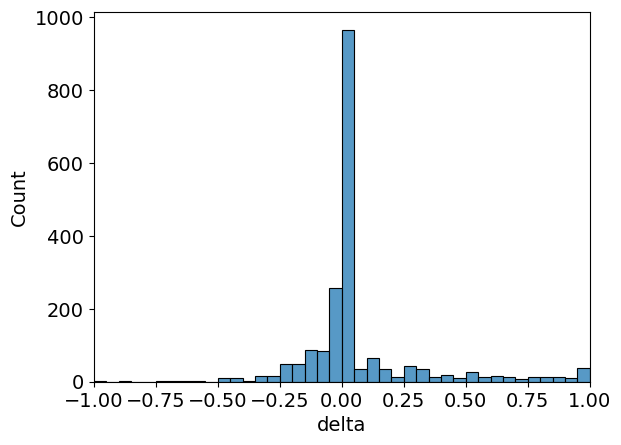

In [103]:
f, ax = plt.subplots(1, 1)
sns.histplot(data=df_items_delta, x="delta", binwidth=.05, ax=ax)
ax.set_xlim(-1, 1)

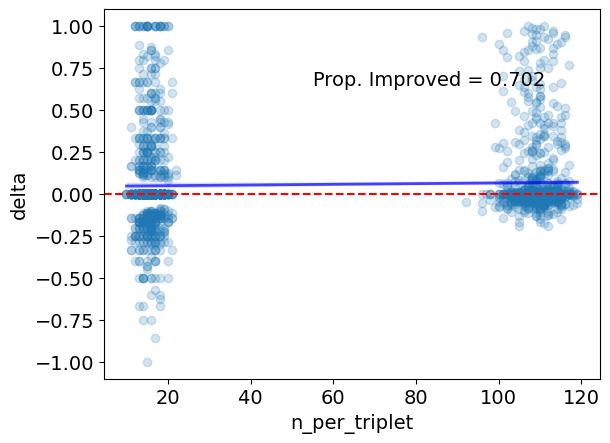

In [101]:
_ = sns.regplot(
    data=df_items_delta,
    x="n_per_triplet",
    y="delta",
    scatter=True,  # Set to False if you only want the smooth line, not the scatter
    line_kws={"color": "blue", "lw": 2, "alpha": .7}, 
    scatter_kws={"alpha": .2}
)
plt.axhline(y=0, color="red", linestyle="--", label="No Improvement")
_ = plt.text(x=55, y=.65, s=f"Prop. Improved = {prop_triplets_improved}")

In [87]:
# Group by 'correct_avg_bin' and compute the weighted average of 'delta'
df_summary = (
    df_items_delta.groupby(["Accuracy Avg. Model"])
    .apply(lambda g: pd.Series({
        "Delta": (g["delta"] * g["n_per_triplet"]).sum() / g["n_per_triplet"].sum(),
        "Total Nr. Responses": g["n_per_triplet"].sum()
    }))
    .reset_index()
)
df_summary["Proportion Responses"] = df_summary["Total Nr. Responses"] / df_summary["Total Nr. Responses"].sum(axis=0)
df_summary["Proportion Delta"] = df_summary["Proportion Responses"] * df_summary["Delta"]

/tmp/ipykernel_3095442/3583352406.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


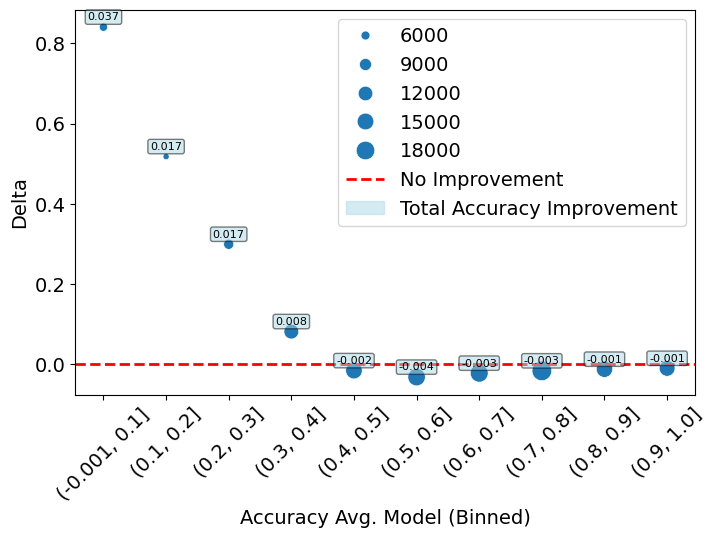

In [88]:
# Step 1: Generate your plot
f, ax = plt.subplots(1, 1, figsize=(8, 5))
scatter = sns.scatterplot(
    data=df_summary,
    x="Accuracy Avg. Model",
    y="Delta",
    size="Total Nr. Responses",
    sizes=(20, 200),
    legend='brief',
    ax=ax, 
)
ax.set_xlabel("Accuracy Avg. Model (Binned)")
# Step 2: Horizontal line with label
ax.axhline(y=0, color="red", linestyle='--', linewidth=2, label='No Improvement')

# Step 3: Add text labels
for i, row in df_summary.iterrows():
    ax.text(
        row["Accuracy Avg. Model"],
        row["Delta"] + 0.025,
        f"{str(np.round(row['Proportion Delta'], 3))}",
        fontsize=8,
        ha='center',
        va='center',
        bbox=dict(boxstyle="round,pad=0.2", fc="lightblue", alpha=0.5)
    )

# Step 4: Create a proxy handle for the ax.text labels
label_proxy = mpatches.Patch(color='lightblue', alpha=0.5, label='Accuracy Improvement')

# Step 5: Combine all handles
handles, labels = ax.get_legend_handles_labels()
handles.append(label_proxy)
labels.append('Total Accuracy Improvement')

# Step 6: Show legend with all entries
ax.legend(handles=handles, labels=labels)

_ = plt.xticks(ticks=range(len(labels_accuracy_binned.cat.categories)),
           labels=labels_accuracy_binned.cat.categories, rotation=45)

In [89]:
# Group by 'correct_avg_bin' and compute the weighted average of 'delta'
df_items_delta["prop_max_rounded"] = np.round(df_items_delta["prop_max"], 1)
df_summary = (
    df_items_delta.groupby(["prop_max_rounded"])
    .apply(lambda g: pd.Series({
        "Delta": (g["delta"] * g["n_per_triplet"]).sum() / g["n_per_triplet"].sum(),
        "Total Nr. Responses": g["n_per_triplet"].sum()
    }))
    .reset_index()
)
df_summary["Proportion Responses"] = df_summary["Total Nr. Responses"] / df_summary["Total Nr. Responses"].sum(axis=0)
df_summary["Proportion Delta"] = df_summary["Proportion Responses"] * df_summary["Delta"]

/tmp/ipykernel_3095442/2878315084.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [90]:
# save df with information about individual triplets
df_items_delta.to_csv("data/triplets-delta.csv")

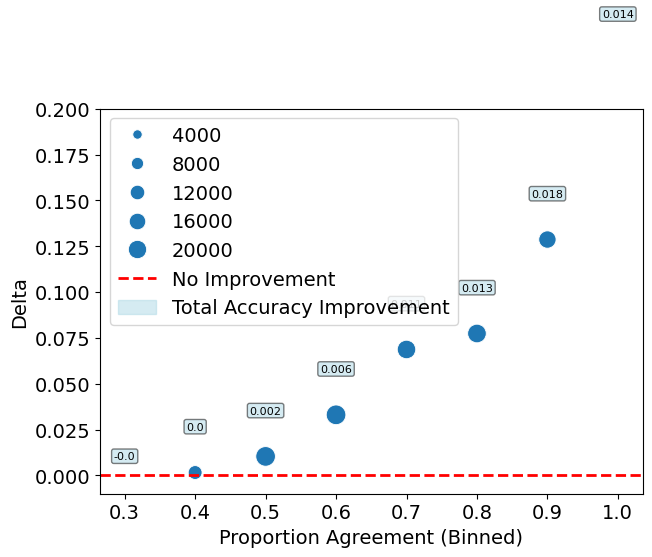

In [91]:
# Step 1: Generate your plot
f, ax = plt.subplots(1, 1, figsize=(7, 5))
scatter = sns.scatterplot(
    data=df_summary,
    x="prop_max_rounded",
    y="Delta",
    size="Total Nr. Responses",
    sizes=(20, 200),
    legend='brief',
    ax=ax, 
)
ax.set_xlabel("Proportion Agreement (Binned)")
# Step 2: Horizontal line with label

# Step 3: Add text labels
for i, row in df_summary.iterrows():
    ax.text(
        row["prop_max_rounded"],
        row["Delta"] + 0.025,
        f"{str(np.round(row['Proportion Delta'], 3))}",
        fontsize=8,
        ha='center',
        va='center',
        bbox=dict(boxstyle="round,pad=0.2", fc="lightblue", alpha=0.5)
    )

# Add horizontal line (don't need to save handle if it gets captured automatically)
ax.axhline(y=0, color="red", linestyle='--', linewidth=2, label='No Improvement')

# Proxy handle for Accuracy Improvement text annotations
label_proxy = mpatches.Patch(color='lightblue', alpha=0.5, label='Accuracy Improvement')

# Collect handles and labels, then deduplicate using a dictionary
handles, labels = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels, handles))  # removes duplicates by label

# Add the custom Accuracy Improvement label, only if it's not already present
legend_dict['Total Accuracy Improvement'] = label_proxy

ax.set_ylim((-0.01, 0.2))

# Draw the final legend
_ = ax.legend(legend_dict.values(), legend_dict.keys())

In [92]:
l_concepts = os.listdir("data/images/")
l_m = [re.match("^[a-z]", l_concepts[i]) for i in range(0, len(l_concepts))]
l_filter = [l_m[i] != None for i in range(0, len(l_concepts))]
l_concepts_filtered = [value for value, flag in zip(l_concepts, l_filter) if flag]
f_partial = partial(ut.extract_image, l_concepts_filtered)

FileNotFoundError: [Errno 2] No such file or directory: 'data/images/'

In [ ]:
np.corrcoef(df_items_delta["delta"], df_items_delta["prop_max"])

In [ ]:
n_triplets_plot = 15
top_disagreed_triplets = df_items_delta.query(
    "n_per_triplet >= 100 & delta >= 0.05").sort_values("prop_max").head(
    n_triplets_plot)["triplet_id"].reset_index(drop=True)

In [ ]:
df_delta_disagree = pd.merge(pd.DataFrame(top_disagreed_triplets), df_items_delta, how="left", on="triplet_id")
plt.hist(data=df_delta_disagree, x="delta", bins=30)
plt.axvline(x=0, color="red", linestyle="--", label="No Improvement")
_ = plt.legend()

In [ ]:
f, axes = plt.subplots(n_triplets_plot, 3, figsize=(3 * 1.5, n_triplets_plot * 1.5))

for i, _ in enumerate(top_disagreed_triplets):
    current_ids = df_items_delta.query(
        f"triplet_id == '{top_disagreed_triplets[i]}'"
    ).drop_duplicates(
        ["id_lo", "id_mid", "id_hi", "delta"]
    )[["id_lo", "id_mid", "id_hi", "delta"]]
    
    l_current_ids = [int(l) for l in list(current_ids.values.reshape(-1))]
    path_to_images = list(map(f_partial, l_current_ids))

    for j in range(3):
        img = Image.open(path_to_images[j])
        axes[i, j].imshow(img)
        axes[i, j].axis("off")

    # Add row number at the center-left of the row
    axes[i, 0].text(
        -0.1, 0.5,  # slightly outside the image
        f"{str(i + 1)}, d={np.round(current_ids["delta"].values[0], 2)}",
        fontsize=12,
        va='center',
        ha='right',
        transform=axes[i, 0].transAxes
    )

plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

In [ ]:
df_plt_prop

In [ ]:
idx_l = [0, 30]
l_ndim = [20, 50]
j = 0

f, ax = plt.subplots(1)

for idx, ndim in zip(idx_l, l_ndim):

    l_prop_prop = []
    df_embeddings_full = pd.DataFrame(l_all_models_id_2[idx]["model_state_dict"]["fc.weight"].detach().numpy().transpose()).reset_index()
    df_embeddings_full.columns = ["image_id"] + [i for i in range(0, ndim)]
    
    for dim in range(0, ndim):
        df_plt_prop = df_embeddings_full.copy()
        df_plt_prop[dim] = df_plt_prop[dim] / df_plt_prop[dim].max()
        df_plt_prop.sort_values(dim, inplace=True)
        df_plt_prop = df_plt_prop.reset_index(drop=True)
        prop_prop = df_plt_prop.index/df_plt_prop.index.max()
        l_prop_prop.append(df_plt_prop[dim])
        ax.plot(prop_prop, df_plt_prop[dim], c=["orange", "blue"][j], alpha=.1)
    df_prop_prop = pd.DataFrame(l_prop_prop).transpose()
    df_prop_prop["avg"] = df_prop_prop.mean(axis=1)
    ax.plot(df_prop_prop["avg"].index/df_prop_prop.index.max(), df_prop_prop["avg"], c=["orange", "blue"][j], linewidth=3, alpha=.5)
    j += 1

In [ ]:
import re
l_concepts = os.listdir("data/images/")
l_m = [re.match("^[a-z]", l_concepts[i]) for i in range(0, len(l_concepts))]
l_filter = [l_m[i] != None for i in range(0, len(l_concepts))]
l_concepts_filtered = [value for value, flag in zip(l_concepts, l_filter) if flag]
f_partial = partial(ut.extract_image, l_concepts_filtered)

In [ ]:
df_dim_cor = pd.DataFrame(np.corrcoef(df_embeddings_full[range(0, 50)].transpose()))
np_cor_abs = np.abs(df_dim_cor.to_numpy())
np_cor_abs[np_cor_abs > .9999] = 0

# How Do Individual Decision Weights Affect The Dimensional Weights?

In [137]:
l_models_decision[2]["splithalf"] = "1"
l_models_decision[2]["item_embeddings"] = l_models_decision[2]["model_state_dict"]["model1.fc.weight"]
l_models_decision[2]["decision_weights"] = l_models_decision[2]["model_state_dict"]["model1.individual_slopes.weight"]

l_models_embedding_only[0]["splithalf"] = "2"
l_models_embedding_only[0]["item_embeddings"] = l_models_embedding_only[0]["model_state_dict"]["fc.weight"]
l_models_embedding_only[0]["decision_weights"] = l_models_embedding_only[0]["model_state_dict"]["individual_slopes.weight"]

l_compare_weightpresence = [l_models_decision[2], l_models_embedding_only[0]]

In [138]:
l_n = [15, 15]

In [139]:
partial_sims = partial(ut.dimensional_similarities, l_compare_weightpresence)
l_cors = list(map(partial_sims, l_n))

In [140]:
# reorder dimensions in the two halves according to the max. similar result
partial_reorder = partial(ut.reorder_dimensions, l_compare_weightpresence)
l_max_sims = list(map(partial_reorder, l_n))

In [164]:
df_weights_decision = pd.DataFrame(l_models_decision[2]["model_state_dict"]["model1.individual_slopes.weight"].detach().numpy())
df_weights_embedding = pd.DataFrame(l_models_embedding_only[0]["model_state_dict"]["individual_slopes.weight"].detach().numpy())

In [165]:
df_weights_decision = df_weights_decision.reset_index().rename(columns={"index":"pid"})
df_weights_decision["decision"] = "fit"

In [166]:
df_weights_embedding = df_weights_embedding.reset_index().rename(columns={"index":"pid"})
df_weights_embedding["decision"] = "fixed"

In [169]:
df_compare_decision = pd.merge(
    df_weights_decision.melt(id_vars=["pid", "decision"]),
    df_weights_embedding.melt(id_vars=["pid", "decision"]),
    how="left", on=["pid", "variable"], suffixes=["_fit", "_fixed"]
)

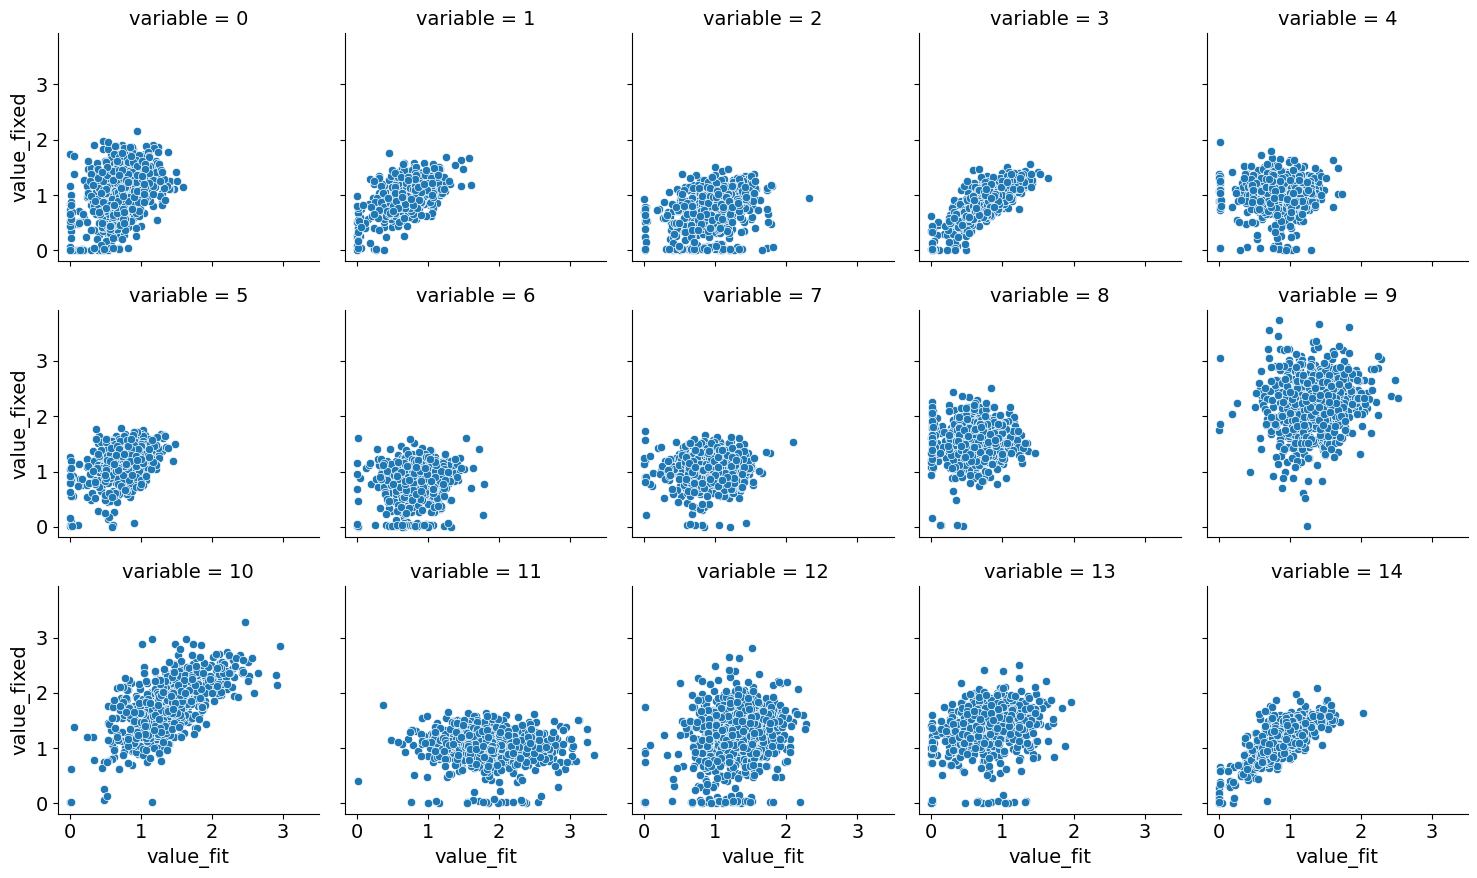

In [172]:
g = sns.FacetGrid(data=df_compare_decision, col="variable", col_wrap=5)
g.map_dataframe(sns.scatterplot, x="value_fit", y="value_fixed")

In [170]:
df_compare_decision.head()

,pid,decision_fit,variable,value_fit,decision_fixed,value_fixed
0,0,fit,0,0.930430,fixed,0.262551
1,1,fit,0,0.607794,fixed,1.065205
2,2,fit,0,0.601309,fixed,0.826550
3,3,fit,0,0.951709,fixed,1.353836
4,4,fit,0,0.118941,fixed,0.474060
